# 1. Import Libraries

In [2233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer, PowerTransformer

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score



# 2. Load Data

In [2234]:
customers = pd.read_csv("Wholesale_customers_data.csv")

In [2235]:
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2236]:
customers.shape

(440, 8)

In [2237]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [2238]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


# 3. EDA

### 3.1 Check for duplicates

In [2239]:
customers.duplicated().sum()

np.int64(0)

### 3.2 Correlation Heatmap

<Axes: >

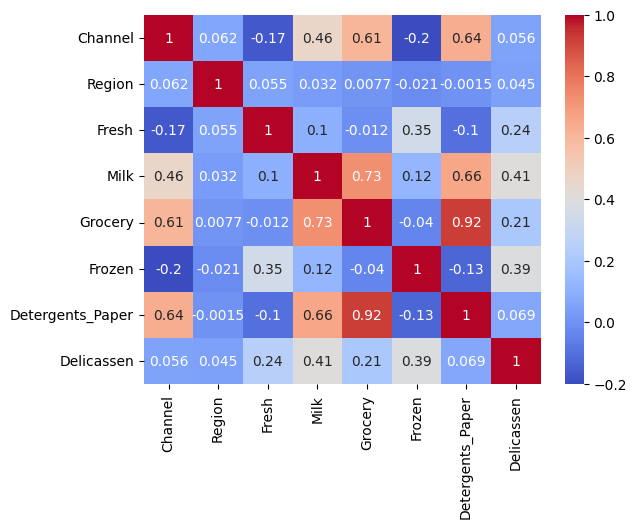

In [2240]:
customer_corr = customers.corr()
sns.heatmap(customer_corr, cmap='coolwarm', annot=True)


Channel
1    0.677273
2    0.322727
Name: proportion, dtype: float64

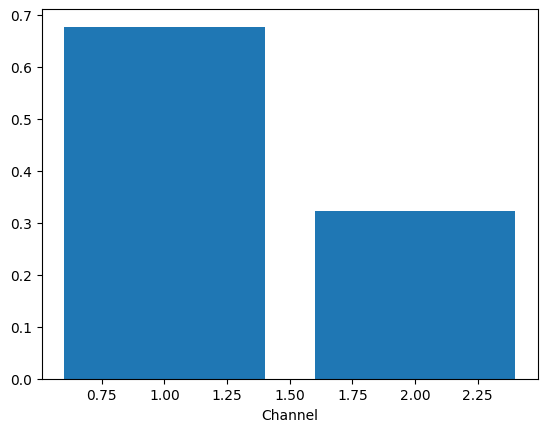

In [2241]:
count = customers["Channel"].value_counts(normalize=True)
plt.bar(count.index, count.values)
plt.xlabel("Channel")
count

Region
3    0.718182
1    0.175000
2    0.106818
Name: proportion, dtype: float64

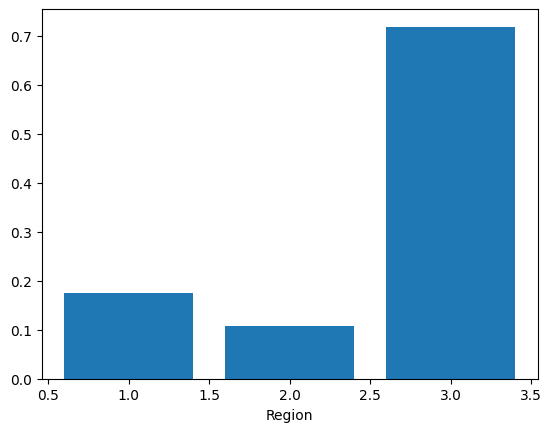

In [2242]:
count = customers["Region"].value_counts(normalize=True)
plt.bar(count.index, count.values)
plt.xlabel("Region")
count

In [2243]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] #'Channel', 'Region', 

### 3.3 Distribution of Numeric features

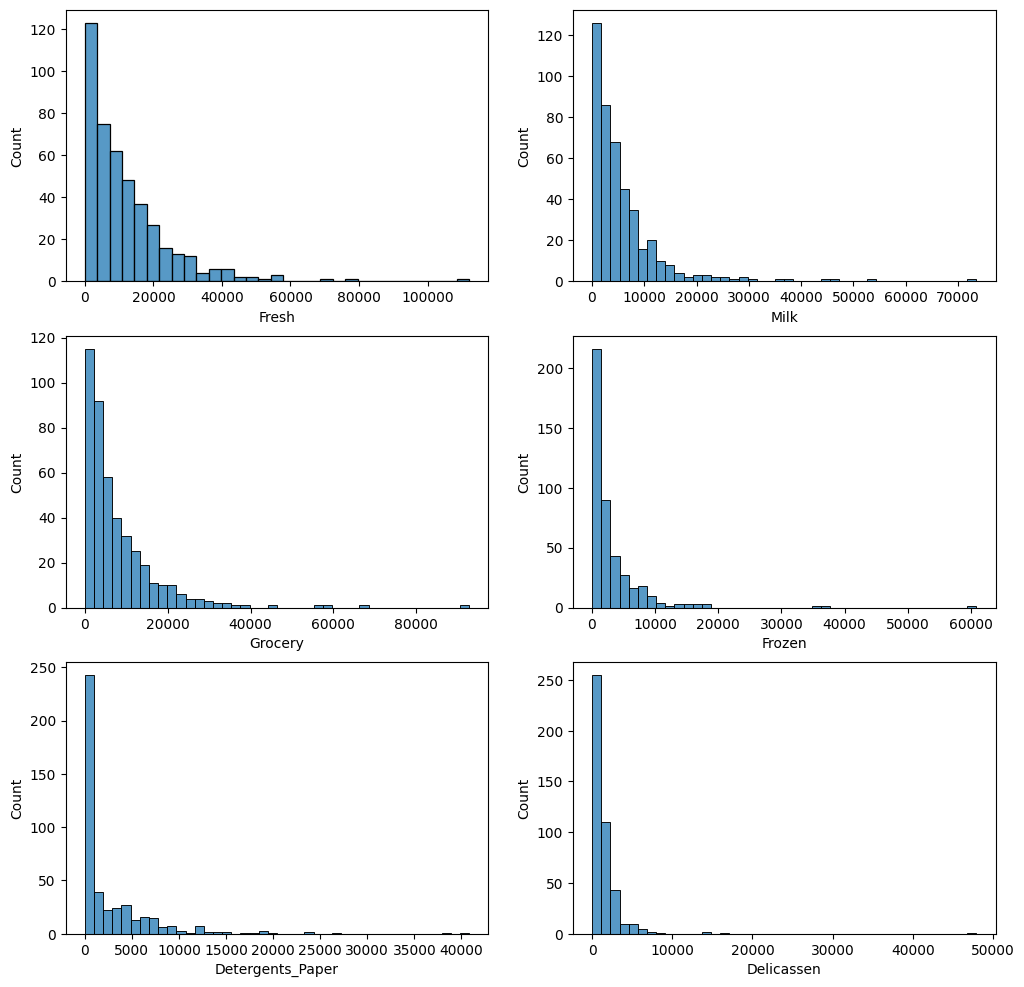

In [2244]:
fig, axes = plt.subplots(3,2, figsize=(12,12))
axes = axes.flatten()
for index, col in enumerate(features):
    sns.histplot(data=customers[col], ax=axes[index])

### 3.4 Check for outliers

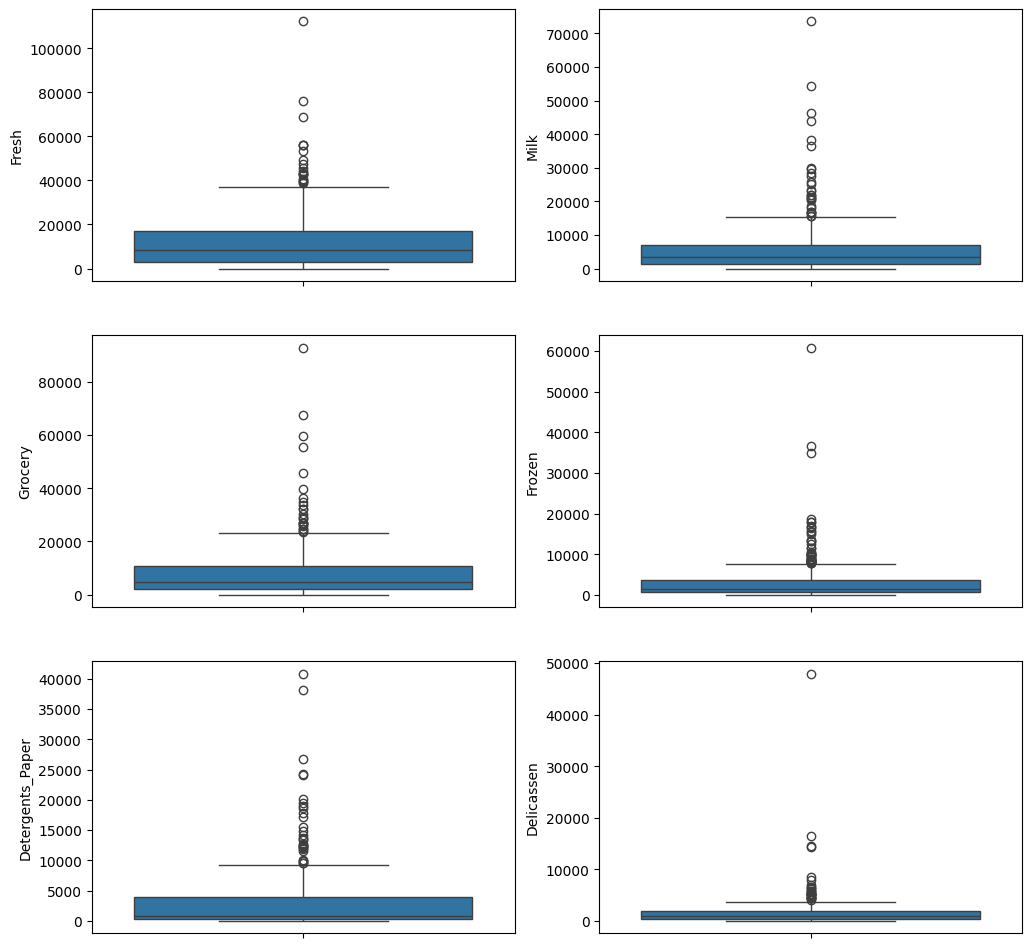

In [2245]:
fig, axes = plt.subplots(3,2, figsize=(12,12))
axes = axes.flatten()
for index, col in enumerate(features):
    sns.boxplot(data=customers[col], ax=axes[index])


EDA Sumamry
- There is no missing value
- There are no duplicate rows
- All the features contains outliers
- drop Channel and Region features

### drop Channel and Region

In [2246]:
customers.drop(columns=["Channel", "Region"], inplace=True)
customers.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


# Execution Plan

First cluster the dataset with raw data(standardized), then cluster after applying log transform(due to the long tail nature of each feature) and standardizing. Will compare the clustering using PCA.

# 4. Clustering with raw data

## 4.1 K-means

###  Preprocessing

In [2247]:
preprocessor = ColumnTransformer(transformers=[
    ('standardscalar', StandardScaler(), features)
])

X_std = preprocessor.fit_transform(customers[features])

### Find optimal value of K

In [2248]:
K = list(range(2, 20, 1))
wcss_list = []
s_scores = []

for k in K:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std)
    wcss = model.inertia_
    wcss_list.append(wcss)

    labels = model.predict(X_std) 
    slh_score = silhouette_score(X_std, labels, metric='euclidean')
    s_scores.append(slh_score)

print(wcss_list)
print(s_scores)


[2287.422176333924, 1619.952782172456, 1331.5282387206569, 1085.4920859712865, 991.570584003924, 836.4738484014911, 744.168576706691, 663.1174557573443, 605.9151092090292, 573.4611622292396, 534.1578693557354, 502.8015825904554, 488.27584523697215, 465.6730768957664, 437.01773696877933, 398.1878985223053, 381.88508351778205, 358.5711285142331]
[0.8638007202163266, 0.33391714199926514, 0.35947985064567445, 0.3537351220198272, 0.35964419211953047, 0.33182337060982603, 0.32631529253158853, 0.33325906746583445, 0.3112143583568513, 0.29853042791629475, 0.2848217165737234, 0.2867335756853637, 0.287436353815166, 0.26446549792832863, 0.2649842776954829, 0.2653241339331971, 0.2647755017857447, 0.2652453824385047]


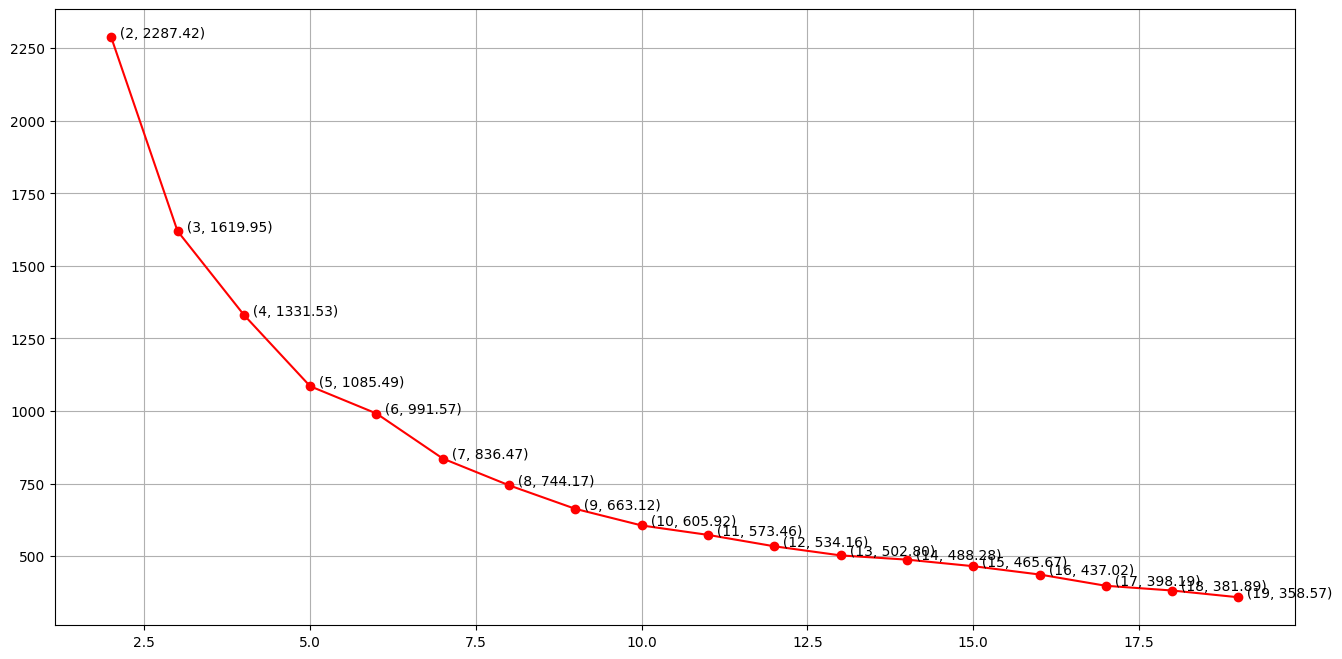

In [2249]:
plt.figure(figsize=(16,8))
plt.plot(K, wcss_list, "ro-")
#plt.plot(K, np.array(s_scores)*10)

for x, y in zip(K, wcss_list):
    plt.text(x, y, f"  ({x}, {y:.2f})")
plt.grid()

In [2250]:
for k in [2, 3, 4, 5, 6, 7, 8, 9]:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std) 
    labels = model.predict(X_std)

    wcss_kmeans = model.inertia_
    s_score_kmeans = silhouette_score(X_std, labels, metric='euclidean')

    print(k)
    print(f"k-means WCSS: {round(wcss_kmeans,3)}")
    print(f"Silhouette Score: {round(s_score_kmeans,3)}")
    print()

2
k-means WCSS: 2287.422
Silhouette Score: 0.864

3
k-means WCSS: 1619.953
Silhouette Score: 0.334

4
k-means WCSS: 1331.528
Silhouette Score: 0.359

5
k-means WCSS: 1085.492
Silhouette Score: 0.354

6
k-means WCSS: 991.571
Silhouette Score: 0.36

7
k-means WCSS: 836.474
Silhouette Score: 0.332

8
k-means WCSS: 744.169
Silhouette Score: 0.326

9
k-means WCSS: 663.117
Silhouette Score: 0.333



Fit the Kmeans cluster with right k value.
from the above excercise we can safely use k=4 as optimum number of clusters

### Fit the model with optimal K value

In [2251]:
no_of_clusters = 4
model_kmeans = KMeans(n_clusters=no_of_clusters, random_state=9)
labels_kmeans = model_kmeans.fit_predict(X_std)
labels_kmeans

array([0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0,
       0, 3, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2,
       2, 2, 2, 1, 2, 2, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 2, 0, 1,
       0, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 1, 1, 3,
       0, 0, 0, 0, 1, 3, 2, 0, 0, 0, 0, 0, 2, 2, 2, 3, 0, 0, 2, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 3, 2, 3, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 3, 2,
       0, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 2, 2, 2, 0, 2, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0,

In [2252]:
def plot_clusters_counts(labels):    
    value_counts = Counter(labels)

    clusters = list(value_counts.keys())
    counts = list(value_counts.values())

    plt.figure(figsize=(8,4))
    plt.bar(clusters, counts)
    plt.title("Cluster Distribution")
    plt.xlabel("Clusters")
    plt.xticks(list(value_counts.keys()))

    for x, y in zip(clusters, counts):
        plt.text(x=x, y=y, s=str(y))


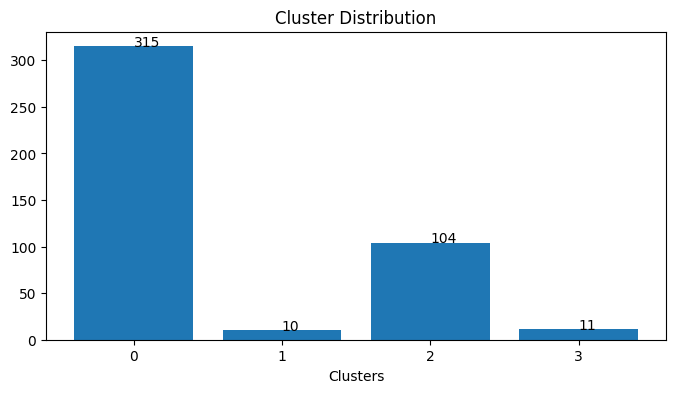

In [2253]:
plot_clusters_counts(labels_kmeans)

In [2254]:
centroids = model_kmeans.cluster_centers_
centroids


array([[ 6.13257056e-02, -3.61390762e-01, -4.33205084e-01,
        -1.15474402e-02, -4.19218367e-01, -1.46394431e-01],
       [ 3.13830315e-01,  3.92190593e+00,  4.27561037e+00,
        -3.57419457e-03,  4.61816580e+00,  5.03365339e-01],
       [-5.05799570e-01,  5.98794088e-01,  8.49097197e-01,
        -3.49707960e-01,  8.48519263e-01,  4.65919826e-02],
       [ 2.74065953e+00,  1.12222232e+00,  4.90671759e-01,
         3.64025577e+00, -2.15806886e-01,  3.29409328e+00]])

### Sillhouette Score

In [2255]:
silhouette_score_kmeans = silhouette_score(X_std, labels_kmeans, metric='euclidean')
silhouette_score_kmeans

0.35947985064567445

In [2256]:
results =[]

In [2257]:

results.append({
    "Model Name" : "KMeans with standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans,
    "Predicted Labels": labels_kmeans
  })

pd.DataFrame(results)


,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.35948,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."


### Cluster visualization with PCA
Check how separable the data is after KMeans clustering

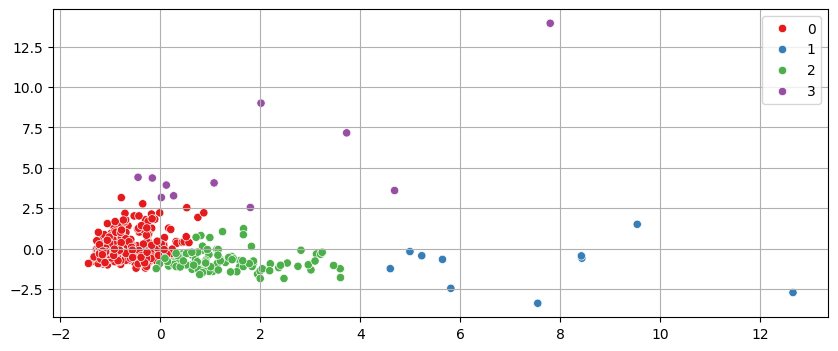

In [2258]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans, palette="Set1")
plt.grid()

In [2259]:
# customers["Cluster"] = labels_kmeans
# customers.to_csv("clusterd_4.csv")

In [2260]:
customers_std_df = pd.DataFrame(X_std)
columns = customers_std_df.columns.to_list()
customers_std_df[6] = labels_kmeans
customers_std_df.head()


,0,1,2,3,4,5,6
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,0
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,2
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,2
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,0
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,0


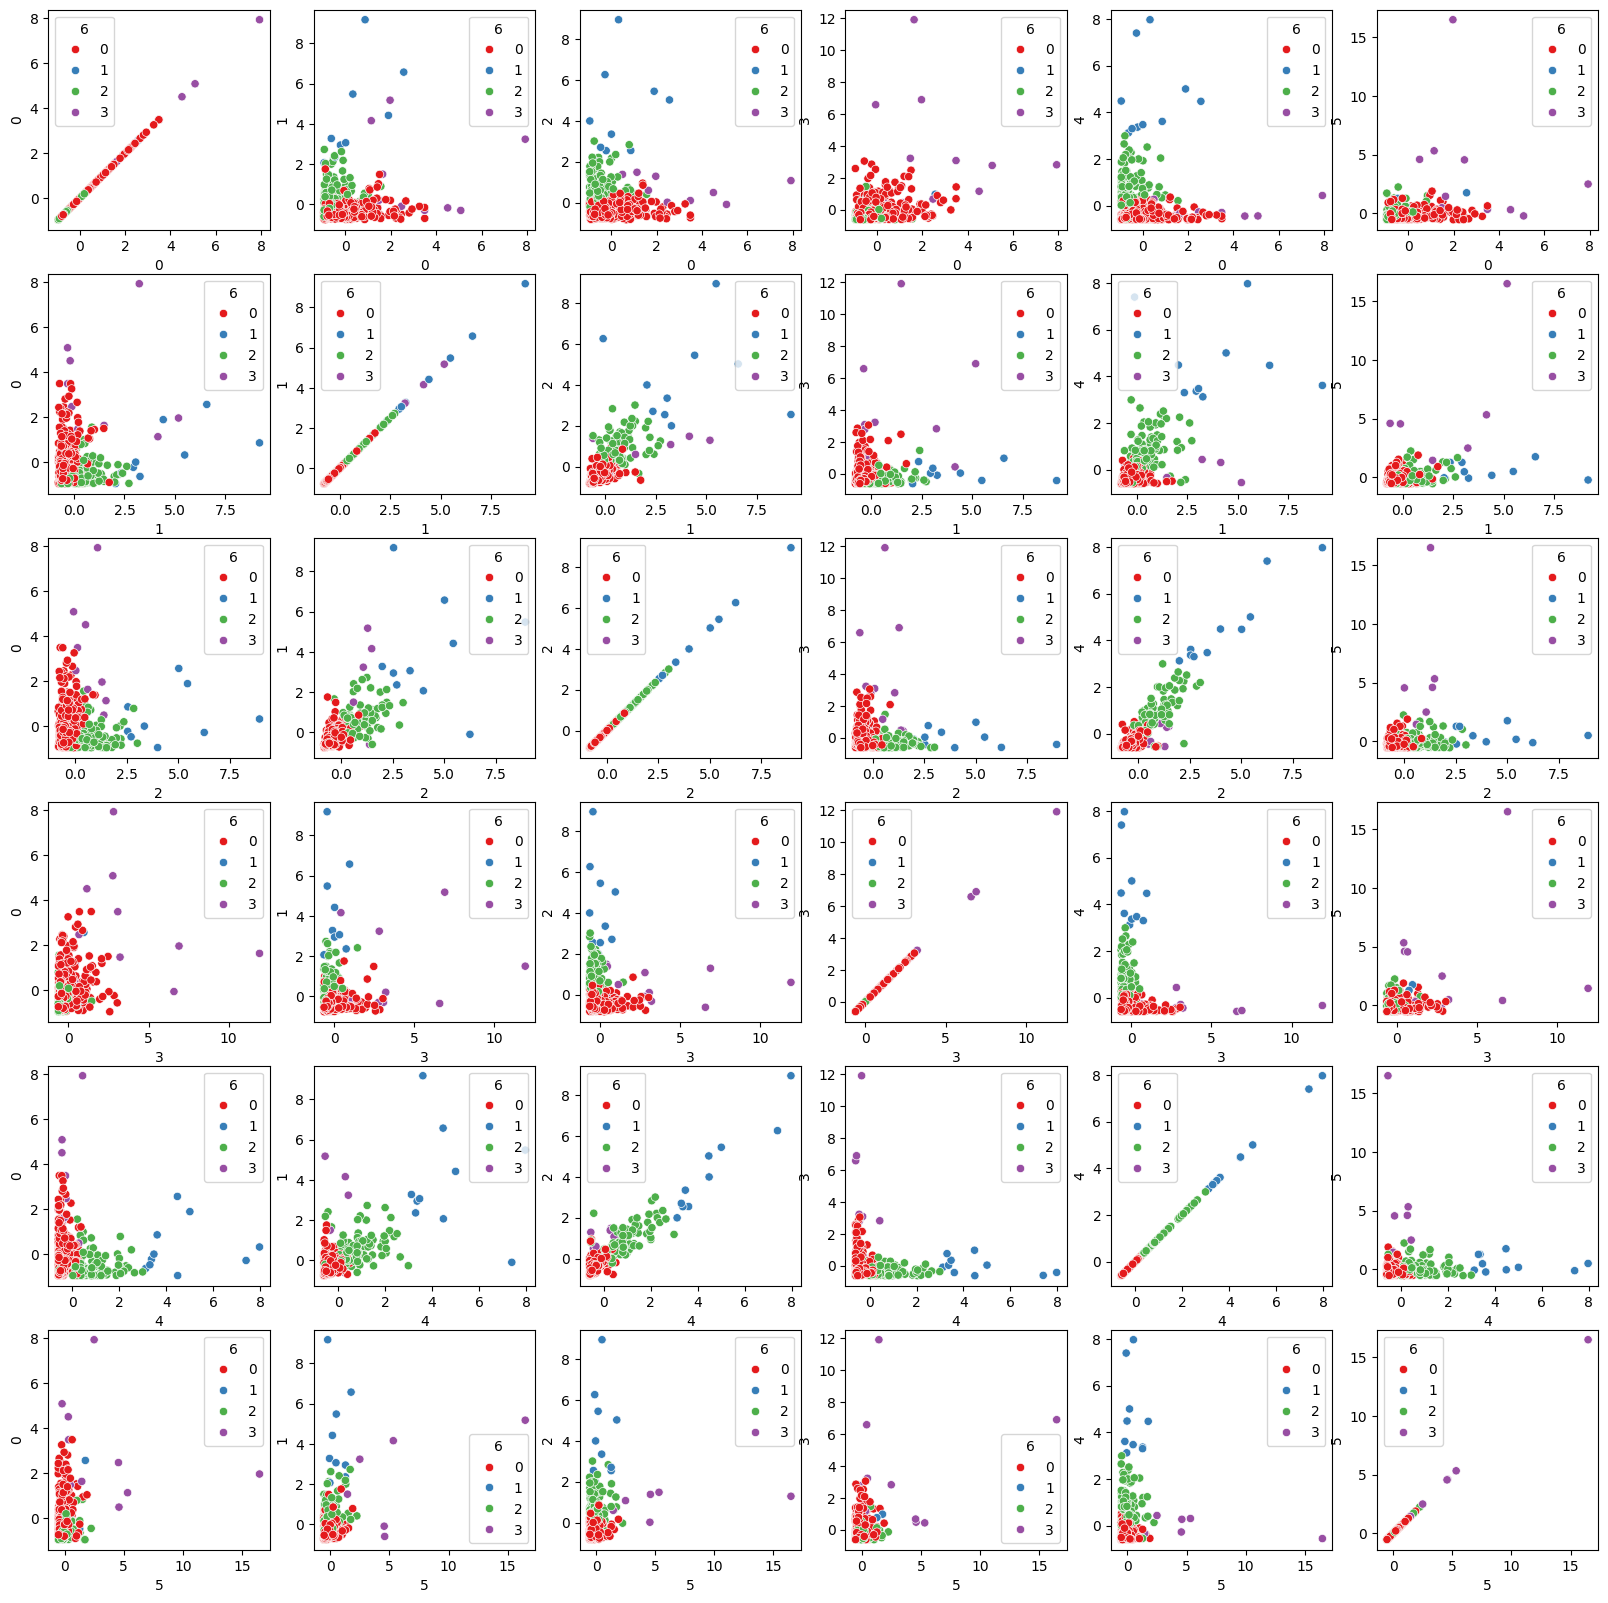

In [2261]:
fig, axes = plt.subplots(6,6, figsize=(20,20))

for col in columns:
    for col1 in columns:
        sns.scatterplot(customers_std_df, x=col, y=col1, hue=6, ax=axes[col][col1], palette="Set1")
        plt.xlabel(col)
        plt.ylabel(col1)

In [2262]:
#sns.pairplot(customers[features+["Cluster"]], hue="Cluster", palette="Set1")

## 4.2 DBScan

### Preprocessing

In [2263]:
# preprocessor = ColumnTransformer(transformers=[
#     ('standard_scaler', StandardScaler(), features)
# ])

# X_std = preprocessor.fit_transform(customers[features])
#X_std = pca.fit_transform(customers[features])

### find optimal eps and min_poins

In [2264]:
eps_list = np.arange(0.1, 1.0, 0.05) 
min_points = np.arange(5, 40, 5)

eps_list, min_points

(array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
        0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95]),
 array([ 5, 10, 15, 20, 25, 30, 35]))

In [2265]:
list(zip(eps_list, min_points))
E, M = np.meshgrid(eps_list, min_points)
eps_minpoints_pairs = list(zip(E.ravel(), M.ravel()))
eps_minpoints_pairs

[(np.float64(0.1), np.int64(5)),
 (np.float64(0.15000000000000002), np.int64(5)),
 (np.float64(0.20000000000000004), np.int64(5)),
 (np.float64(0.25000000000000006), np.int64(5)),
 (np.float64(0.30000000000000004), np.int64(5)),
 (np.float64(0.3500000000000001), np.int64(5)),
 (np.float64(0.40000000000000013), np.int64(5)),
 (np.float64(0.4500000000000001), np.int64(5)),
 (np.float64(0.5000000000000001), np.int64(5)),
 (np.float64(0.5500000000000002), np.int64(5)),
 (np.float64(0.6000000000000002), np.int64(5)),
 (np.float64(0.6500000000000001), np.int64(5)),
 (np.float64(0.7000000000000002), np.int64(5)),
 (np.float64(0.7500000000000002), np.int64(5)),
 (np.float64(0.8000000000000003), np.int64(5)),
 (np.float64(0.8500000000000003), np.int64(5)),
 (np.float64(0.9000000000000002), np.int64(5)),
 (np.float64(0.9500000000000003), np.int64(5)),
 (np.float64(0.1), np.int64(10)),
 (np.float64(0.15000000000000002), np.int64(10)),
 (np.float64(0.20000000000000004), np.int64(10)),
 (np.float64

In [2266]:
def get_optimal_eps_minpoint(values):
    silhouette_scores = []
    out_eps_list = []
    best_score = -1

    for e, m in values:
        dbscan = DBSCAN(eps=e, min_samples=m, metric='euclidean')
        #dbscan.fit(X_std)

        labels = dbscan.fit_predict(X_std)
        unique_labels = set(labels)
        #print(len(unique_labels))
        if len(unique_labels) > 2:

            score = silhouette_score(X_std, labels, metric='euclidean')
            if score > best_score:
                best_score = score
                best_eps = e
                best_min_points = m
                best_unique_lebels = unique_labels

            silhouette_scores.append(score)
            out_eps_list.append(e)
        else:
            silhouette_scores.append(-1)
            out_eps_list.append(e)

    print(silhouette_scores)

    return best_score, best_eps, best_min_points, best_unique_lebels
    

In [2267]:
best_score, best_eps, best_min_points, unique_labels = get_optimal_eps_minpoint(eps_minpoints_pairs)
print(f"Best Silhouette score: {best_score}, best eps: {best_eps}, best min points: {best_min_points}, unique labels: {unique_labels}")

[-1, -1, -0.2587418205554175, -1, -0.12907886358757908, -0.14387697126692678, -0.06793588223143122, -0.1238403701784685, 0.1958113956262888, 0.2248249366234545, 0.12873708738277373, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -0.24373506946367235, -1, -0.12733871569263688, -1, -0.04826344157208048, -0.0146457886410393, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -0.024307206384750278, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 0.005698750869320047, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
Best Silhouette score: 0.2248249366234545, best eps: 0.5500000000000002, best min points: 5, unique labels: {np.int64(0), np.int64(1), np.int64(-1)}


### fit the model

In [2268]:
final_dbscan = DBSCAN(eps = best_eps, min_samples=best_min_points)
final_labels_dbscan = final_dbscan.fit_predict(X_std)


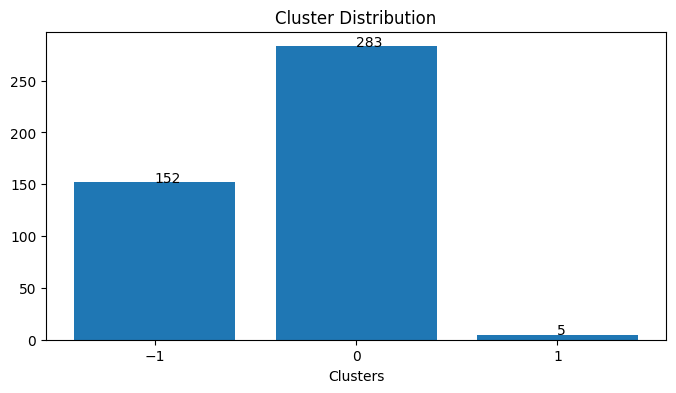

In [2269]:
plot_clusters_counts(final_labels_dbscan)

### Silhouette score

In [2270]:
silhouette_score_dbscan = silhouette_score(X_std, final_labels_dbscan, metric='euclidean')
silhouette_score_dbscan

0.2248249366234545

In [2271]:
no_of_clusters = len(list(Counter(final_labels_dbscan).values()))
results.append({
    "Model Name" : "DBScan with standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_dbscan,
    "Predicted Labels": final_labels_dbscan
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."


### Cluster visualization with PCA

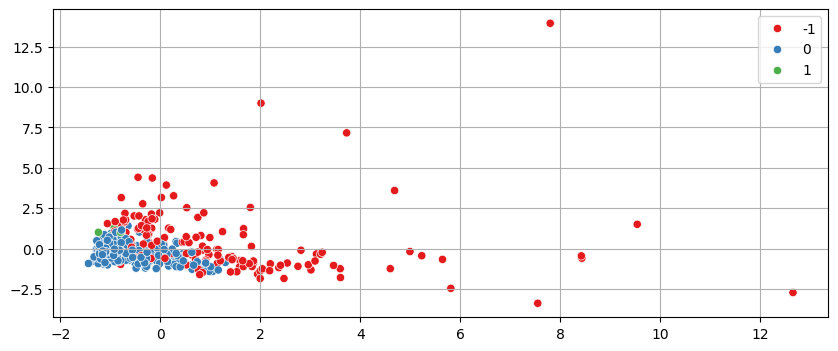

In [2272]:
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=final_labels_dbscan, palette="Set1")
plt.grid()

## 4.4 Agglomerative

### Preprocessing

In [2273]:
# preprocessor = ColumnTransformer(transformers=[
#     ('standardscaler', StandardScaler(), features)
# ])

# X_std = preprocessor.fit_transform(customers[features])

### Fit the model

In [2274]:
model_agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = model_agg.fit_predict(X_std)

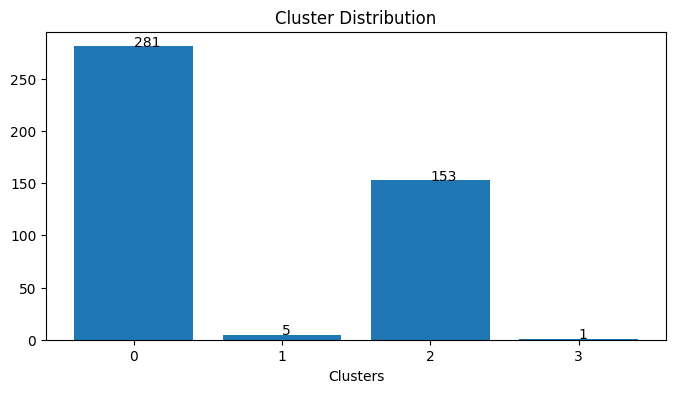

In [2275]:
plot_clusters_counts(labels_agg)

### Silhouette Score

In [2276]:
silhouette_score_agg = silhouette_score(X_std, labels_agg, metric='euclidean')
silhouette_score_agg

0.2670148241989557

In [2277]:
no_of_clusters = 4
results.append({
    "Model Name" : "AgglomerativeClustering with standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_agg,
    "Predicted Labels": labels_agg
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."
2,AgglomerativeClustering with standard transfor...,4,0.267015,"[2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, ..."


### Visualize the clustering with PCA

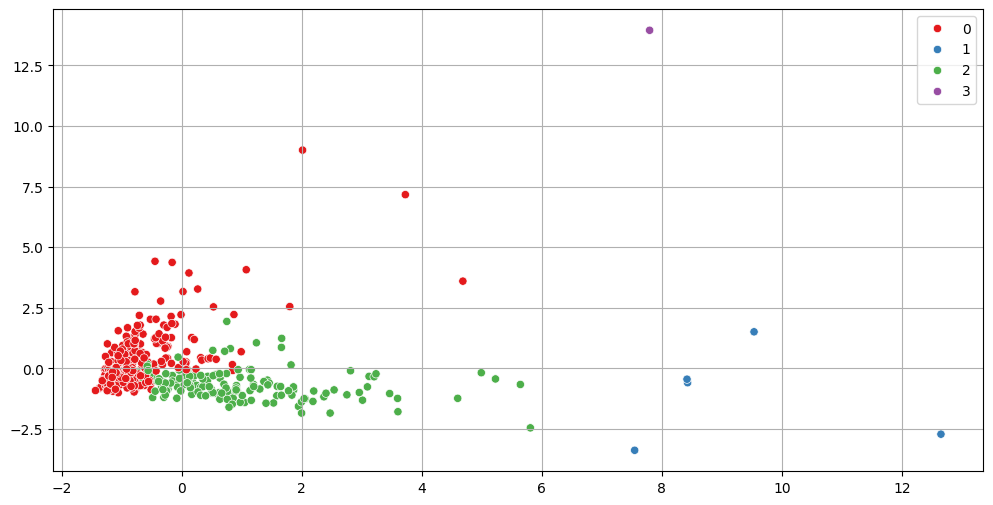

In [2278]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(12,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg, palette="Set1")
plt.grid()

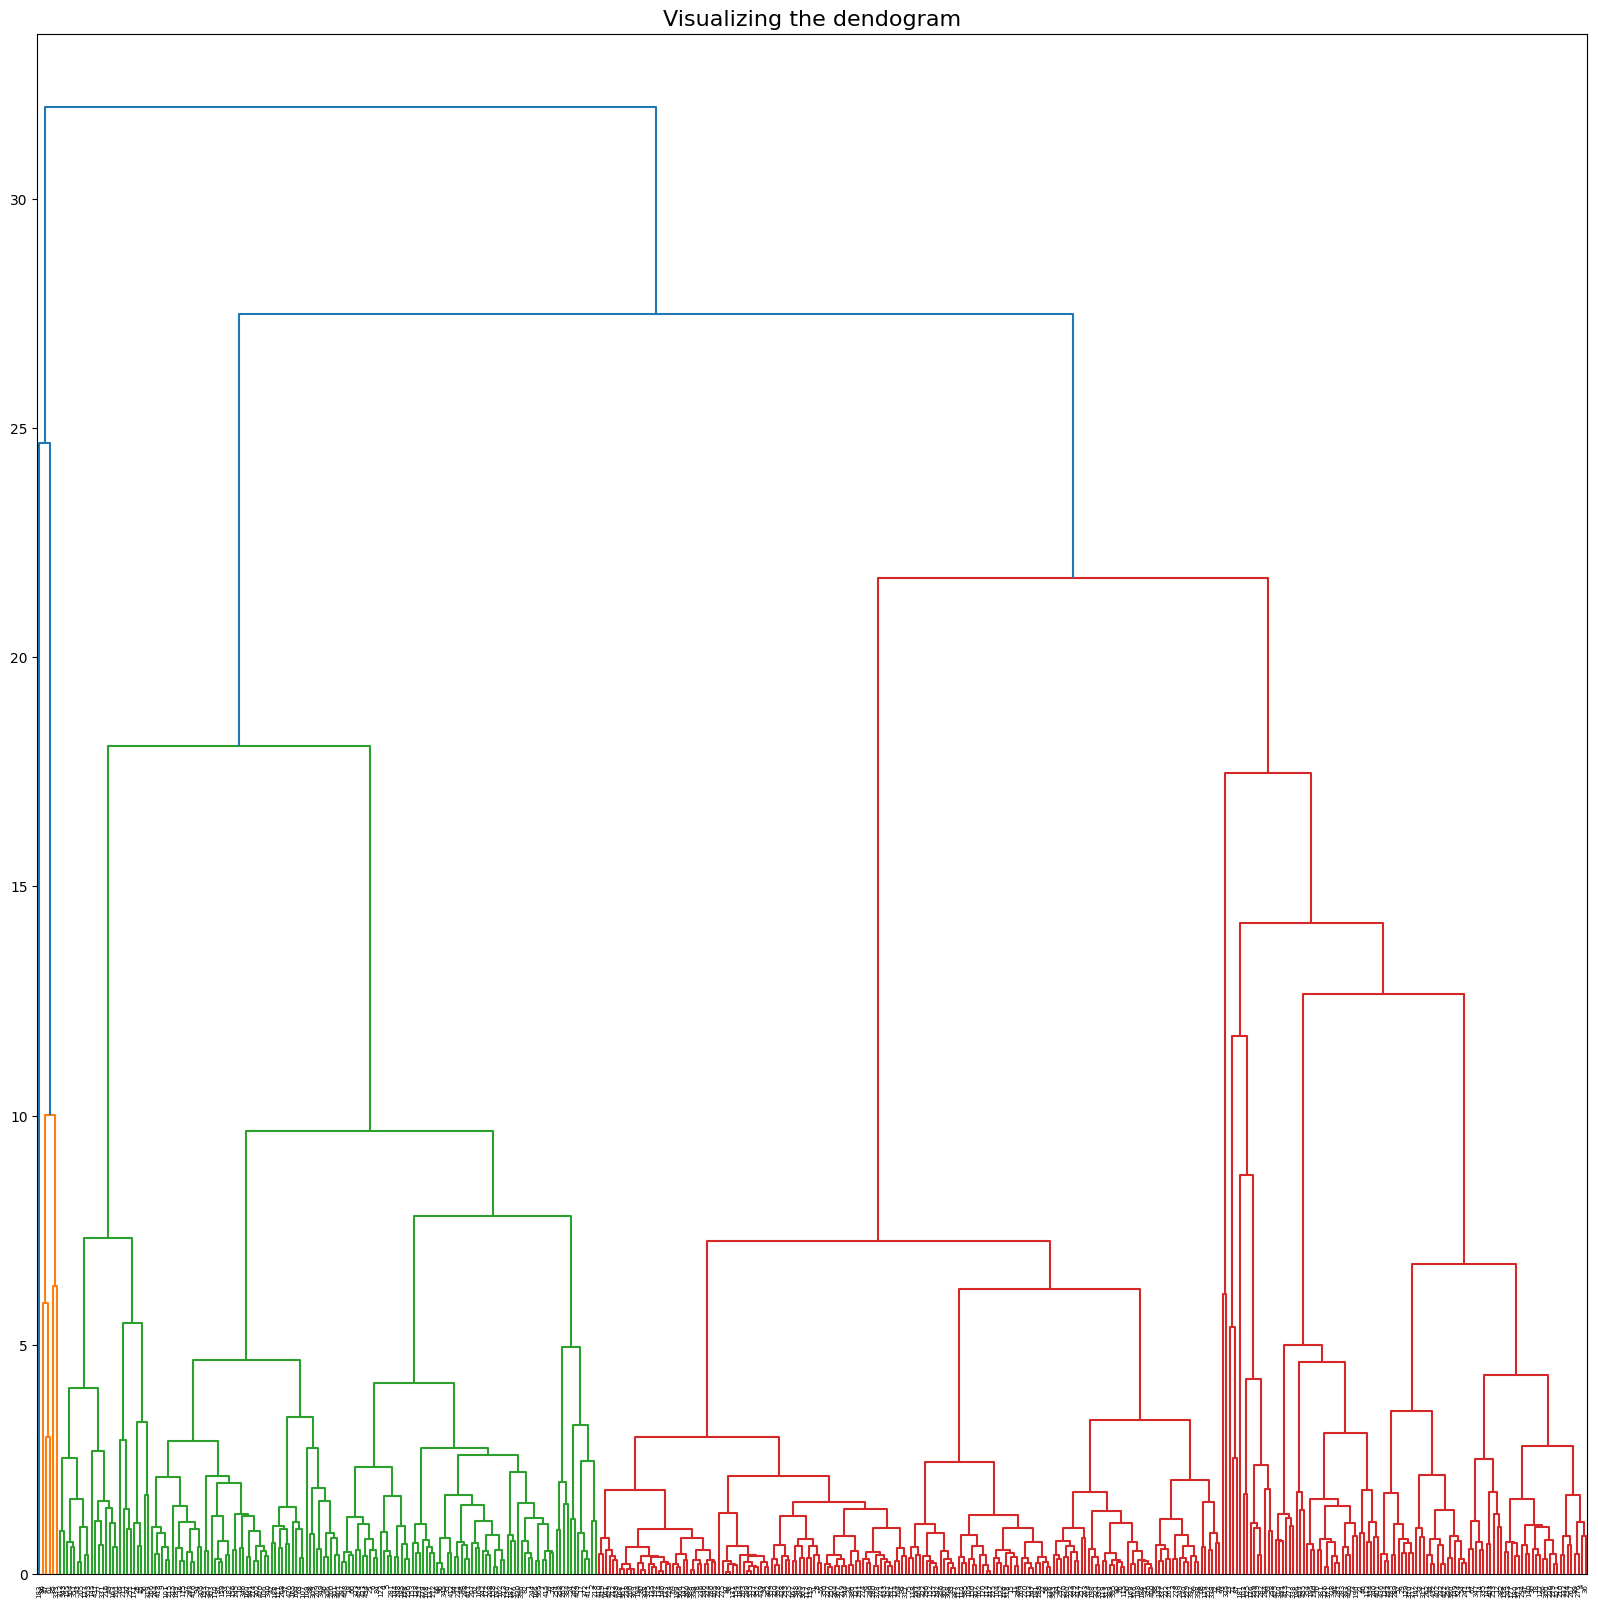

In [2279]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(20,20))
Dendogram = shc.dendrogram((shc.linkage(X_std, method='ward')))
plt.title("Visualizing the dendogram", size=16)
plt.show()

# 5. Clustering with log transformed data data

## 5.1 KMeans

### PreProcessing

In [2280]:
transform_pipeline = Pipeline(steps=[
     ('log', FunctionTransformer(np.log1p, validate=True)),
     ('standard', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('log-standard', transform_pipeline, features)
])
X_std = preprocessor.fit_transform(customers[features])


In [2281]:
for k in [2, 3, 4, 5, 6, 7, 8, 9]:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std) 
    labels = model.predict(X_std)

    wcss_kmeans = model.inertia_
    s_score_kmeans = silhouette_score(X_std, labels, metric='euclidean')

    print(k)
    print(f"k-means WCSS: {round(wcss_kmeans,3)}")
    print(f"Silhouette Score: {round(s_score_kmeans,3)}")
    print()

2
k-means WCSS: 1844.064
Silhouette Score: 0.29

3
k-means WCSS: 1553.446
Silhouette Score: 0.259

4
k-means WCSS: 1438.545
Silhouette Score: 0.227

5
k-means WCSS: 1285.912
Silhouette Score: 0.2

6
k-means WCSS: 1175.739
Silhouette Score: 0.205

7
k-means WCSS: 1088.204
Silhouette Score: 0.19

8
k-means WCSS: 1091.546
Silhouette Score: 0.185

9
k-means WCSS: 1010.05
Silhouette Score: 0.193



### Fit the model

In [2282]:
model_kmeans = KMeans(n_clusters=3, random_state=9)
labels_kmeans_log = model_kmeans.fit_predict(X_std)
labels_kmeans_log

array([0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, 1, 2, 0, 0, 2, 0, 1,
       0, 0, 0, 2, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 2, 2,
       2, 0, 0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 2, 1, 2, 2, 0, 0, 0, 1, 2,
       2, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 2, 0, 1, 2, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 0, 2, 2,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2, 1, 1, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 2,
       0, 1, 1, 1, 0, 0, 2, 0, 2, 1, 1, 2, 0, 2, 1, 1, 1, 2, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 2, 1, 2, 1,
       1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 1, 2, 1, 2, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 2, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       2, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 0, 1, 0,

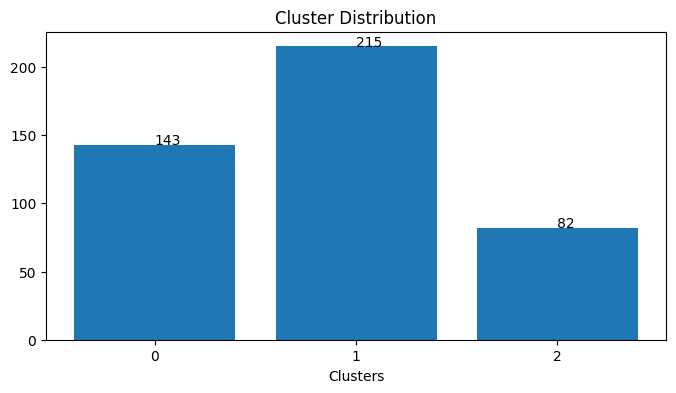

In [2283]:
plot_clusters_counts(labels_kmeans_log)

### Silhouette score

In [2284]:
silhouette_score_kmeans = silhouette_score(X_std, labels_kmeans_log, metric='euclidean')
silhouette_score_kmeans

0.2585248342442102

In [2285]:
no_of_clusters = 3
results.append({
    "Model Name" : "KMeans with log+standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans,
    "Predicted Labels": labels_kmeans_log
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."
2,AgglomerativeClustering with standard transfor...,4,0.267015,"[2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, ..."
3,KMeans with log+standard transformation,3,0.258525,"[0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."


### Cluster visualization with PCA

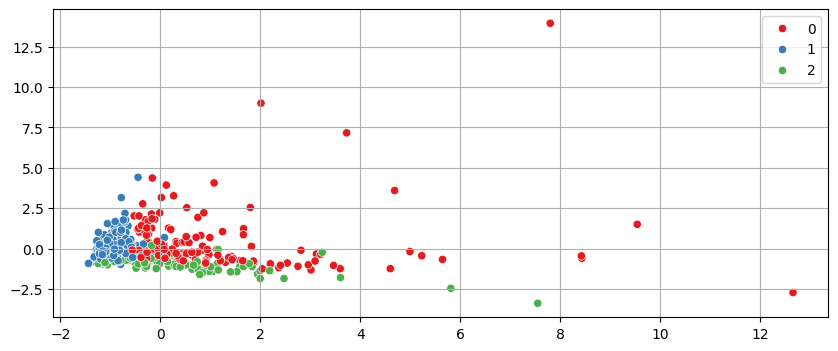

In [2286]:
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans_log, palette="Set1")
plt.grid()

## 5.3 Agglomerative

### Preprocessing

In [2287]:
# transform_pipeline = Pipeline(steps=[
#      ('log', FunctionTransformer(np.log1p, validate=True)),
#      ('standard', StandardScaler())
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('log-standard', transform_pipeline, features)
# ])
# X_std = preprocessor.fit_transform(customers[features])

### fit the model

In [2288]:
model_agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg_log = model_agg.fit_predict(X_std)
silhouette_score_agg = silhouette_score(X_std, labels_agg_log, metric='euclidean')
silhouette_score_agg

0.25465674049413456

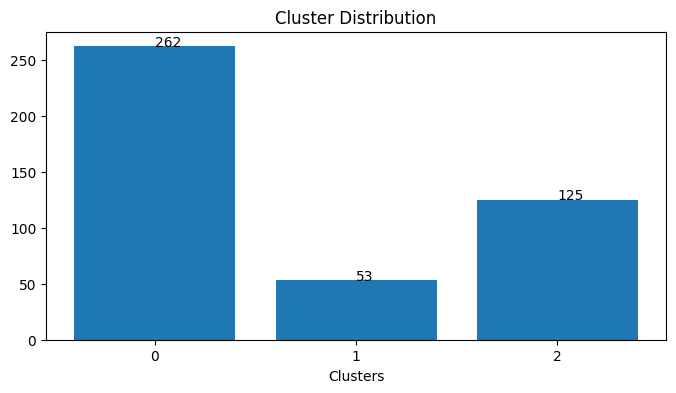

In [2289]:
plot_clusters_counts(labels_agg_log)

In [2290]:
no_of_clusters = 3
results.append({
    "Model Name" : "AgglomerativeClustering with log+standard transformation", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_agg,
    "Predicted Labels": labels_agg_log
  })

pd.DataFrame(results)

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."
2,AgglomerativeClustering with standard transfor...,4,0.267015,"[2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, ..."
3,KMeans with log+standard transformation,3,0.258525,"[0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."
4,AgglomerativeClustering with log+standard tran...,3,0.254657,"[2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, ..."


### Visualize the clustering with PCA

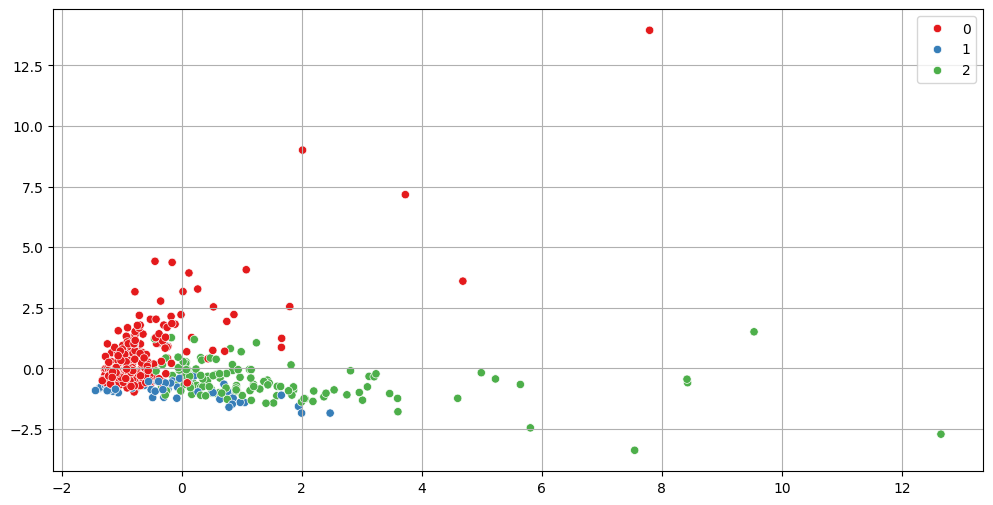

In [2291]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_log, palette="Set1")
plt.grid()

# 6. Clustering without Outliers

In [2292]:
customers = pd.read_csv("Wholesale_customers_data.csv")

In [2293]:
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2294]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] #'Channel', 'Region', 

In [2295]:
customers.duplicated().sum()

np.int64(0)

In [2296]:
outliers = []
customer_no_outlier = customers.copy()

### Remove extreme outliers

In [2297]:
outlier_indices = set()
outliers = []

for col in features:

    #print(f"processing {col} feature")
    q1, q2, q3 = np.quantile(customer_no_outlier[col], [0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower = customer_no_outlier[col].quantile(0.01) #q1 - 2 * iqr
    upper = customer_no_outlier[col].quantile(0.99) #q3 + 2 * iqr

    outlier_count = customer_no_outlier[customer_no_outlier[col] > upper].shape[0] + customer_no_outlier[customer_no_outlier[col] < lower].shape[0]
    #print(customers[customers[col] > upper])

    outliers.append({"Feature": col, "Number_of_Outliers": outlier_count})

    indices = np.where((customer_no_outlier[col] > upper) | (customer_no_outlier[col] < lower))[0]
    #print(customers.iloc[indices, :])
    outlier_indices.update(indices)

   
print(pd.DataFrame(outliers).sort_values(by="Number_of_Outliers", ascending=False))
print(f"Row index to be removed: {list(outlier_indices)}")
print(f"Total Count: {len(outlier_indices)}")  
customer_no_outlier = customer_no_outlier.drop(list(outlier_indices))


print(f"Shape of dataset before outlier removal: {customers.shape}")
print(f"Shape of DataSet after outlier removal: {customer_no_outlier.shape}")

            Feature  Number_of_Outliers
0             Fresh                  10
1              Milk                  10
2           Grocery                  10
3            Frozen                  10
4  Detergents_Paper                  10
5        Delicassen                  10
Row index to be removed: [np.int64(128), np.int64(258), np.int64(142), np.int64(145), np.int64(275), np.int64(23), np.int64(154), np.int64(284), np.int64(161), np.int64(420), np.int64(38), np.int64(39), np.int64(47), np.int64(181), np.int64(183), np.int64(57), np.int64(187), np.int64(61), np.int64(65), np.int64(66), np.int64(196), np.int64(325), np.int64(71), np.int64(75), np.int64(204), np.int64(333), np.int64(338), np.int64(85), np.int64(86), np.int64(87), np.int64(218), np.int64(93), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(356), np.int64(103), np.int64(233), np.int64(109), np.int64(122), np.int64(125)]
Total Count: 42
Shape of dataset before outlier removal: (440, 8)
Shape of DataSet

In [2298]:
customer_no_outlier.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 6.1 KMeans

### preprocessing

In [2299]:
transform_pipeline = Pipeline(steps=[
     ('boxcox', PowerTransformer(method='box-cox')),  #FunctionTransformer(np.log1p, validate=True)),
     ('standard', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('boxcox-standard', transform_pipeline, features)
])
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('boxcox-standard', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``"

In [2300]:
#X_std = preprocessor.fit_transform(customer_no_outlier[features])
X_std = preprocessor.fit_transform(customer_no_outlier[features])
X_std

array([[ 0.47264848,  1.10347347,  0.52026326, -1.58537873,  0.68287352,
         0.39756388],
       [-0.11748364,  1.12072276,  0.76519642,  0.09478454,  0.81744953,
         0.71425645],
       [-0.21249198,  1.00356521,  0.53704083,  0.3759027 ,  0.85986109,
         2.77617018],
       ...,
       [ 0.62729157,  1.62511119,  1.96761998, -1.05770079,  1.79954865,
         0.77239389],
       [ 0.250405  , -0.54917086, -0.74351457, -0.36267826, -1.07734789,
         0.92625644],
       [-0.85834026, -0.70241444, -0.62233724, -2.38217599, -0.41973095,
        -2.04500799]], shape=(398, 6))

### visualize the data after transformation

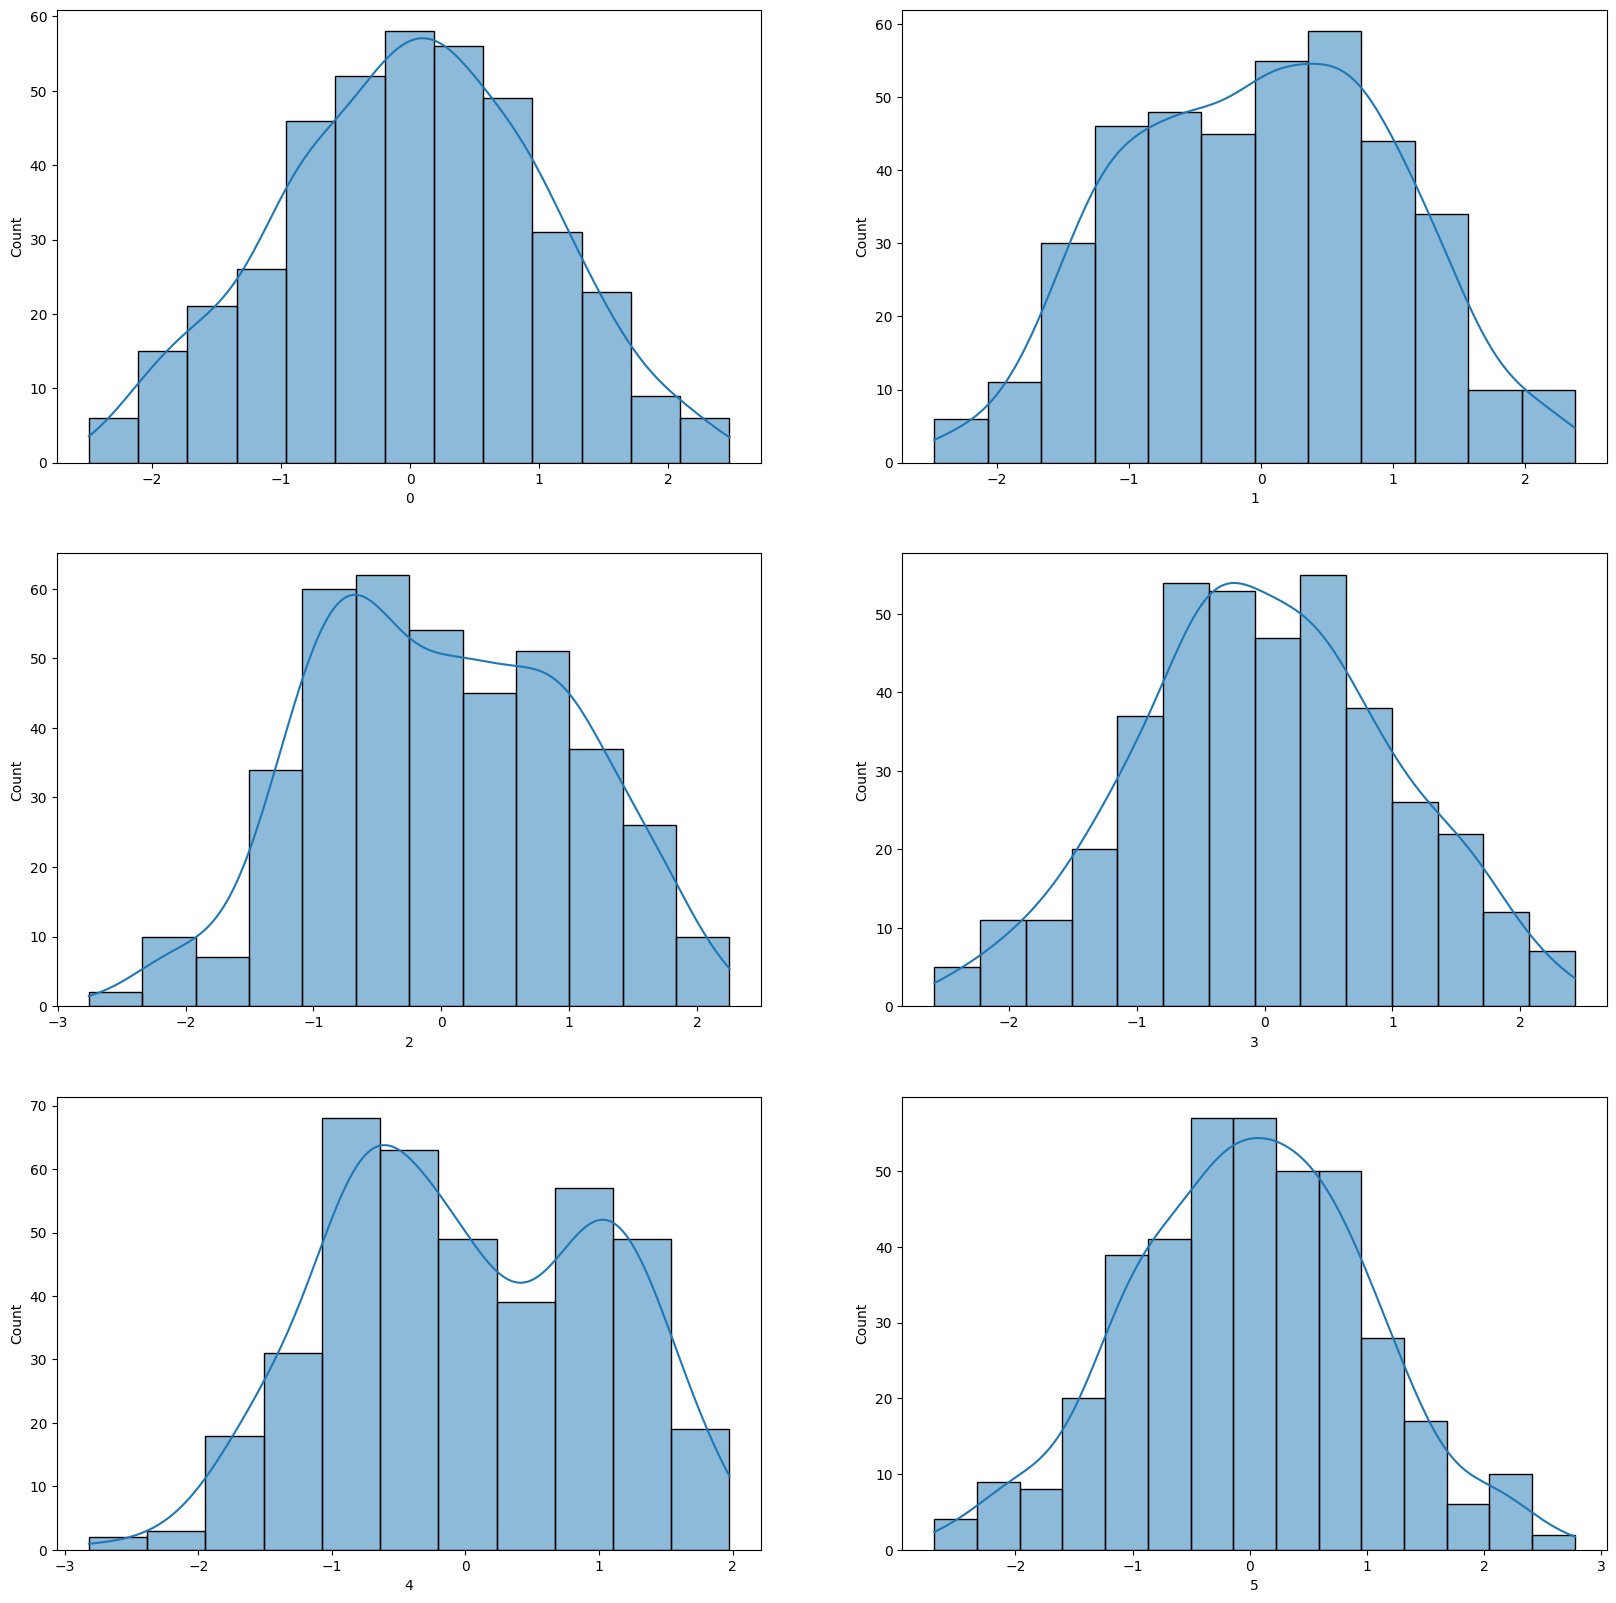

In [2301]:

customers_std_df = pd.DataFrame(X_std)
fig, axes = plt.subplots(3,2, figsize=(20,20))
axes = axes.flatten()

for col in customers_std_df.columns.to_list():
    #sns.histplot(data=customers, x=col, ax=axes[col], kde=True)
    sns.histplot(data=customers_std_df, x=col, ax=axes[col], kde=True)
    plt.xlabel(col)
  

### find optimal value of K

In [2302]:
K = list(range(2, 20, 1))
wcss_list = []
s_scores = []

for k in K:
    model = KMeans(n_clusters=k, random_state=9)
    model.fit(X_std)
    wcss = model.inertia_
    wcss_list.append(wcss)

    labels = model.predict(X_std) 
    slh_score = silhouette_score(X_std, labels, metric='euclidean')
    s_scores.append(slh_score)

print(wcss_list)
print(s_scores)


[1590.021893436975, 1344.1690327489955, 1194.3551540135827, 1104.6626583214122, 1015.5155878545014, 947.7245205208014, 892.7028209248563, 872.3965085127902, 820.9471838814134, 800.2339481351651, 753.138574204308, 731.9895599001923, 705.1404397199543, 679.5782437533355, 659.8520069436785, 643.1586714735872, 638.1302135416904, 618.5464215792572]
[0.30112424034032825, 0.23527872254989668, 0.20110035438980697, 0.1776989905606074, 0.18212033044034026, 0.18899309275820647, 0.17605400654754524, 0.1633570498537226, 0.1613813056314413, 0.15525520606754808, 0.16415758755068713, 0.16372080271132072, 0.16146048760588516, 0.16605575008777404, 0.167898777009859, 0.15962697354462374, 0.15996729433108056, 0.16273132316919406]


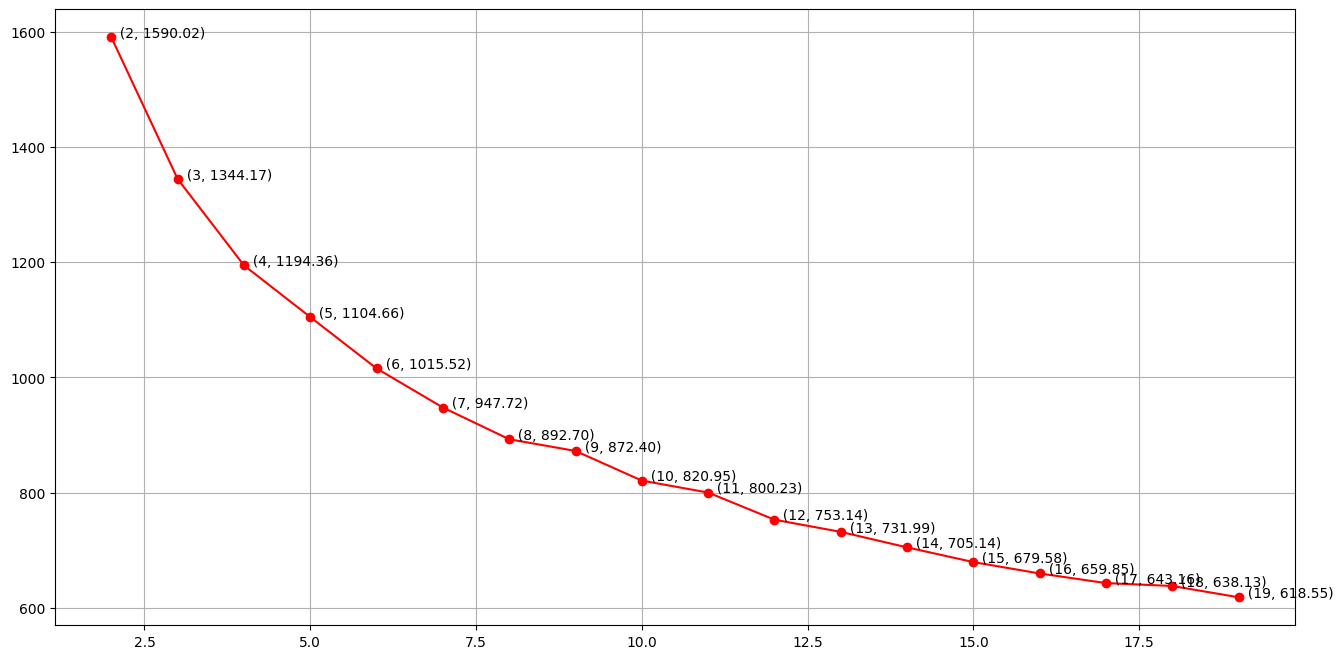

In [2303]:
plt.figure(figsize=(16,8))
plt.plot(K, wcss_list, "ro-")
#plt.plot(K, np.array(s_scores)*10)

for x, y in zip(K, wcss_list):
    plt.text(x, y, f"  ({x}, {y:.2f})")
plt.grid()

In [2304]:
### fit the model

In [2305]:
model_kmeans = KMeans(n_clusters=4, random_state=9)
model_kmeans.fit(X_std)
labels_kmeans_wo_outlier = model_kmeans.predict(X_std)

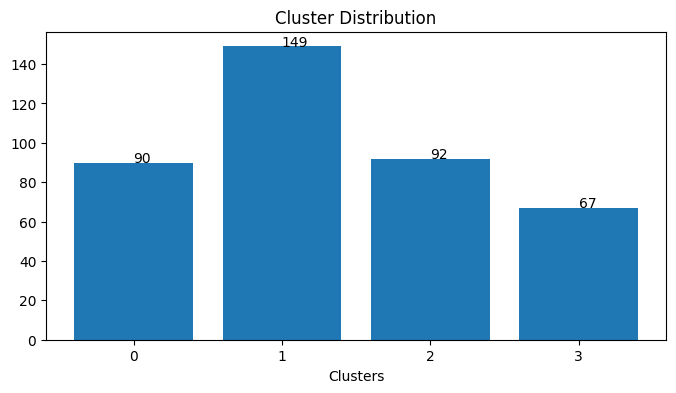

In [2306]:
plot_clusters_counts(labels_kmeans_wo_outlier)


### silhouette score

In [2307]:
silhouette_score_kmeans_wo_outliers = silhouette_score(X_std, labels_kmeans_wo_outlier, metric='euclidean')
silhouette_score_kmeans_wo_outliers

0.20110035438980697

In [2308]:
no_of_clusters = 4
results.append({
    "Model Name" : "KMeans without outliers", 
    "No of Clusters": no_of_clusters,
    "Silhouette Score": silhouette_score_kmeans_wo_outliers,
    "Predicted Labels": labels_kmeans_wo_outlier
  })

results_df = pd.DataFrame(results)
results_df

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."
2,AgglomerativeClustering with standard transfor...,4,0.267015,"[2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, ..."
3,KMeans with log+standard transformation,3,0.258525,"[0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."
4,AgglomerativeClustering with log+standard tran...,3,0.254657,"[2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, ..."
5,KMeans without outliers,4,0.201100,"[2, 2, 2, 0, 0, 2, 3, 2, 3, 2, 2, 1, 2, 2, 2, ..."


### Visialize the cluster with PCA

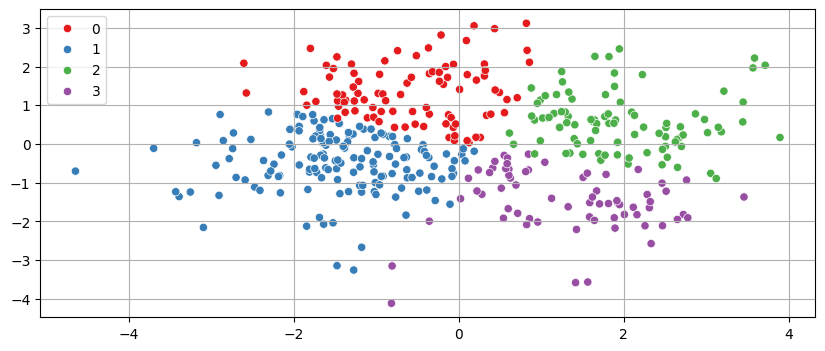

In [2309]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_kmeans_wo_outlier, palette="Set1")
plt.grid()

## 6.2 Agglomerative

In [2310]:
model_agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg_log = model_agg.fit_predict(X_std)
silhouette_score_agg_wo_outliers = silhouette_score(X_std, labels_agg_log, metric='euclidean')
silhouette_score_agg_wo_outliers

0.22266583110082477

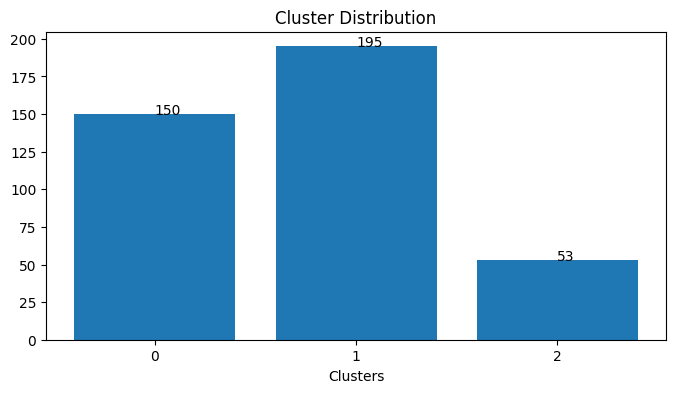

In [2311]:
plot_clusters_counts(labels_agg_log)

In [2312]:
no_of_clusters = 4
results.append({
    "Model Name" : "Agglomerative without outliers", 
    "No of Clusters": 3,
    "Silhouette Score": silhouette_score_agg_wo_outliers,
    "Predicted Labels": labels_agg_log
  })

results_df = pd.DataFrame(results)
results_df

,Model Name,No of Clusters,Silhouette Score,Predicted Labels
0,KMeans with standard transformation,4,0.359480,"[0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 2, 2, ..."
1,DBScan with standard transformation,3,0.224825,"[0, 0, -1, 0, -1, 0, 0, 0, 0, -1, -1, 0, -1, -..."
2,AgglomerativeClustering with standard transfor...,4,0.267015,"[2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, ..."
3,KMeans with log+standard transformation,3,0.258525,"[0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 1, 0, 0, 0, ..."
4,AgglomerativeClustering with log+standard tran...,3,0.254657,"[2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, ..."
5,KMeans without outliers,4,0.201100,"[2, 2, 2, 0, 0, 2, 3, 2, 3, 2, 2, 1, 2, 2, 2, ..."
6,Agglomerative without outliers,3,0.222666,"[0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ..."


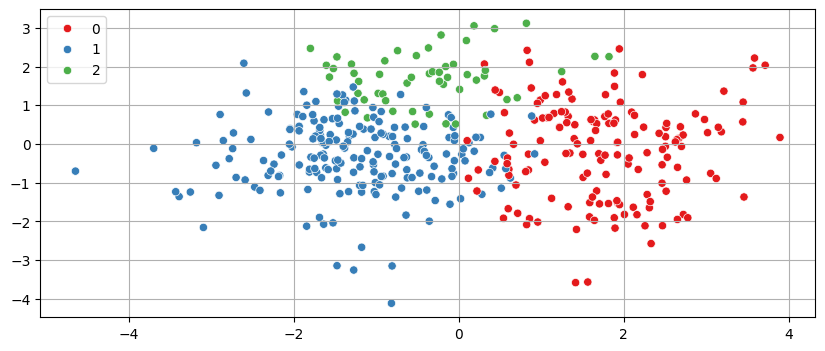

In [2313]:
# pca = PCA(n_components=2, random_state=9)
# X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels_agg_log, palette="Set1")
plt.grid()

# Summary

In [2314]:
# customer_no_outlier["Cluster"] = labels_kmeans
# customer_no_outlier.head()
#customers.to_csv("clusterd.csv")

# box-cox_trasformation

before Transformation

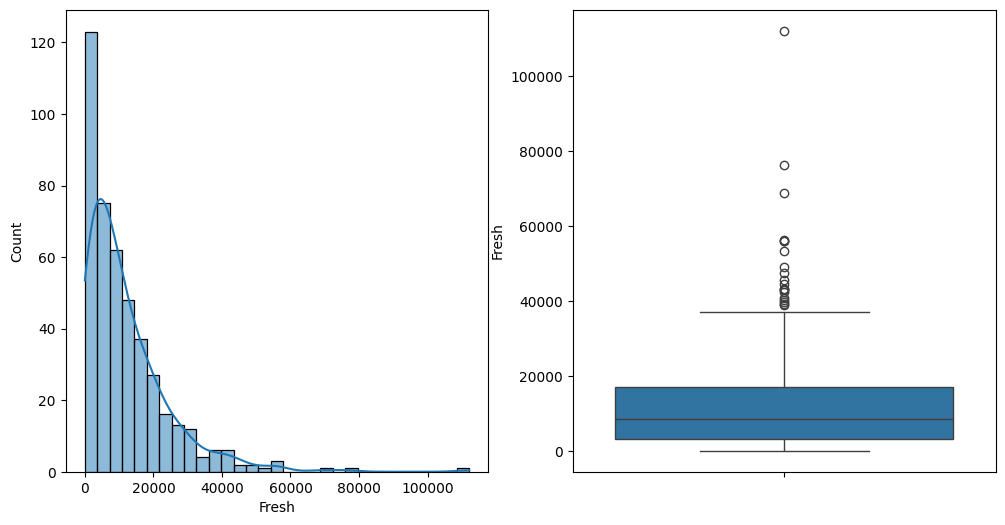

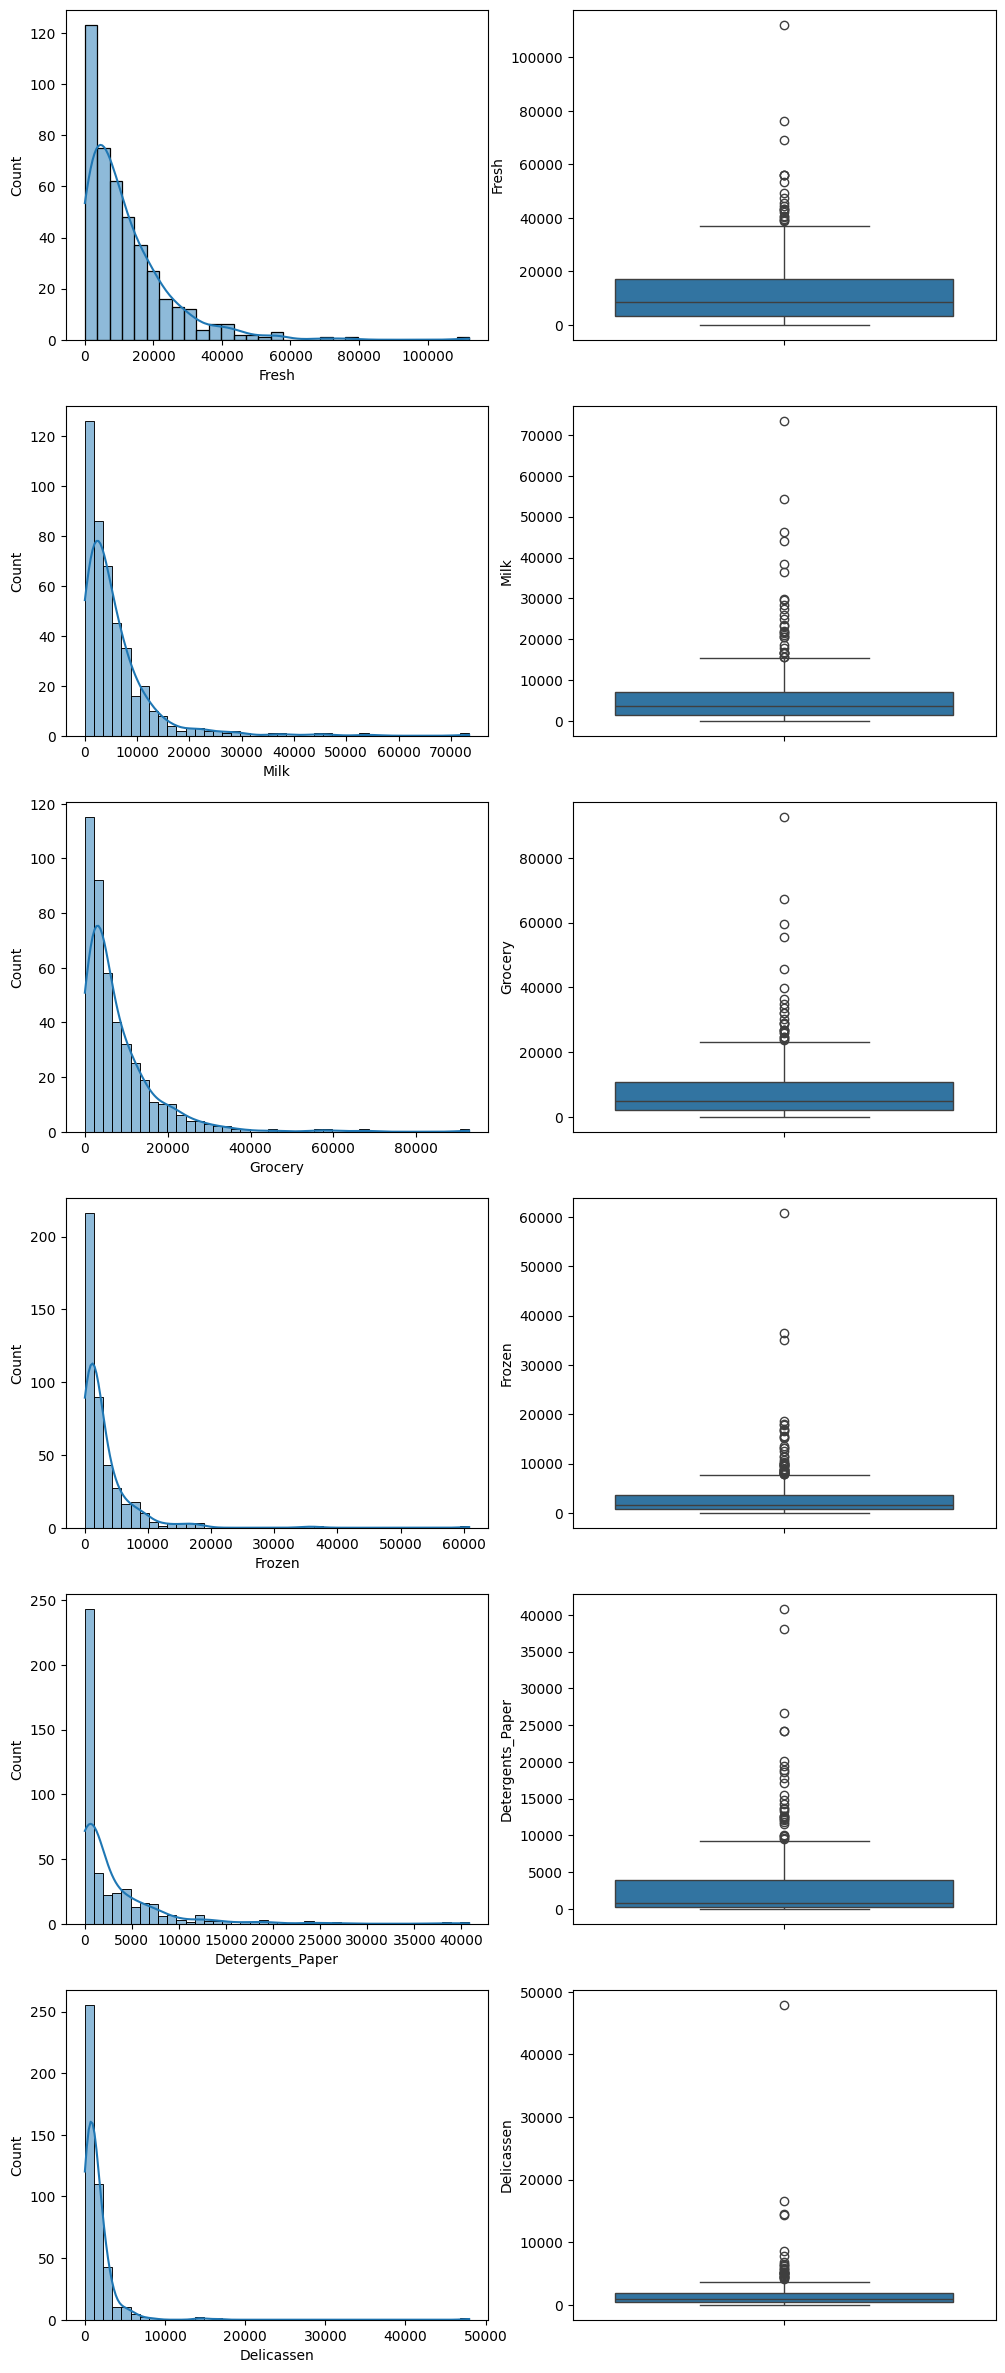

In [2315]:
#customers["Frozen"].hist()
fig, axes = plt.subplots(1,2, figsize = (12,6))

sns.histplot(data=customers, x= customers["Fresh"], kde=True, ax=axes[0])
sns.boxplot(data=customers, y="Fresh")


fig, axes = plt.subplots(6,2, figsize = (12,30))

for i, col in enumerate(features):
    sns.histplot(data=customers, x= customers[col], kde=True, ax=axes[i][0])
    sns.boxplot(data=customers, y=col, ax=axes[i][1])

In [2316]:
# apply box-cox transforemation to mitigate outlier issue

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="box-cox")

transform_pipeline = Pipeline(steps=[
     ('box-cox', PowerTransformer(method="box-cox")),
     ('standardscalar', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ('box-cox', transform_pipeline, features)
])

X_std = preprocessor.fit_transform(customers[features])


In [2317]:
customers[features]

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


In [2318]:
X_std

array([[ 0.41264576,  0.97930343,  0.39293677, -1.45670527,  0.61723793,
         0.33577869],
       [-0.11118039,  0.99509579,  0.62672868,  0.07971785,  0.74862873,
         0.59987651],
       [-0.19604294,  0.88789119,  0.40873795,  0.33199579,  0.79032437,
         2.24529516],
       ...,
       [ 0.54905897,  1.45816343,  1.87674211, -0.96850295,  1.75036735,
         0.64797795],
       [ 0.21600383, -0.5199112 , -0.71201437, -0.33357533, -0.97839273,
         0.77473442],
       [-0.7775091 , -0.65750394, -0.6130534 , -2.20514163, -0.40830878,
        -1.86067522]], shape=(440, 6))

After transformation

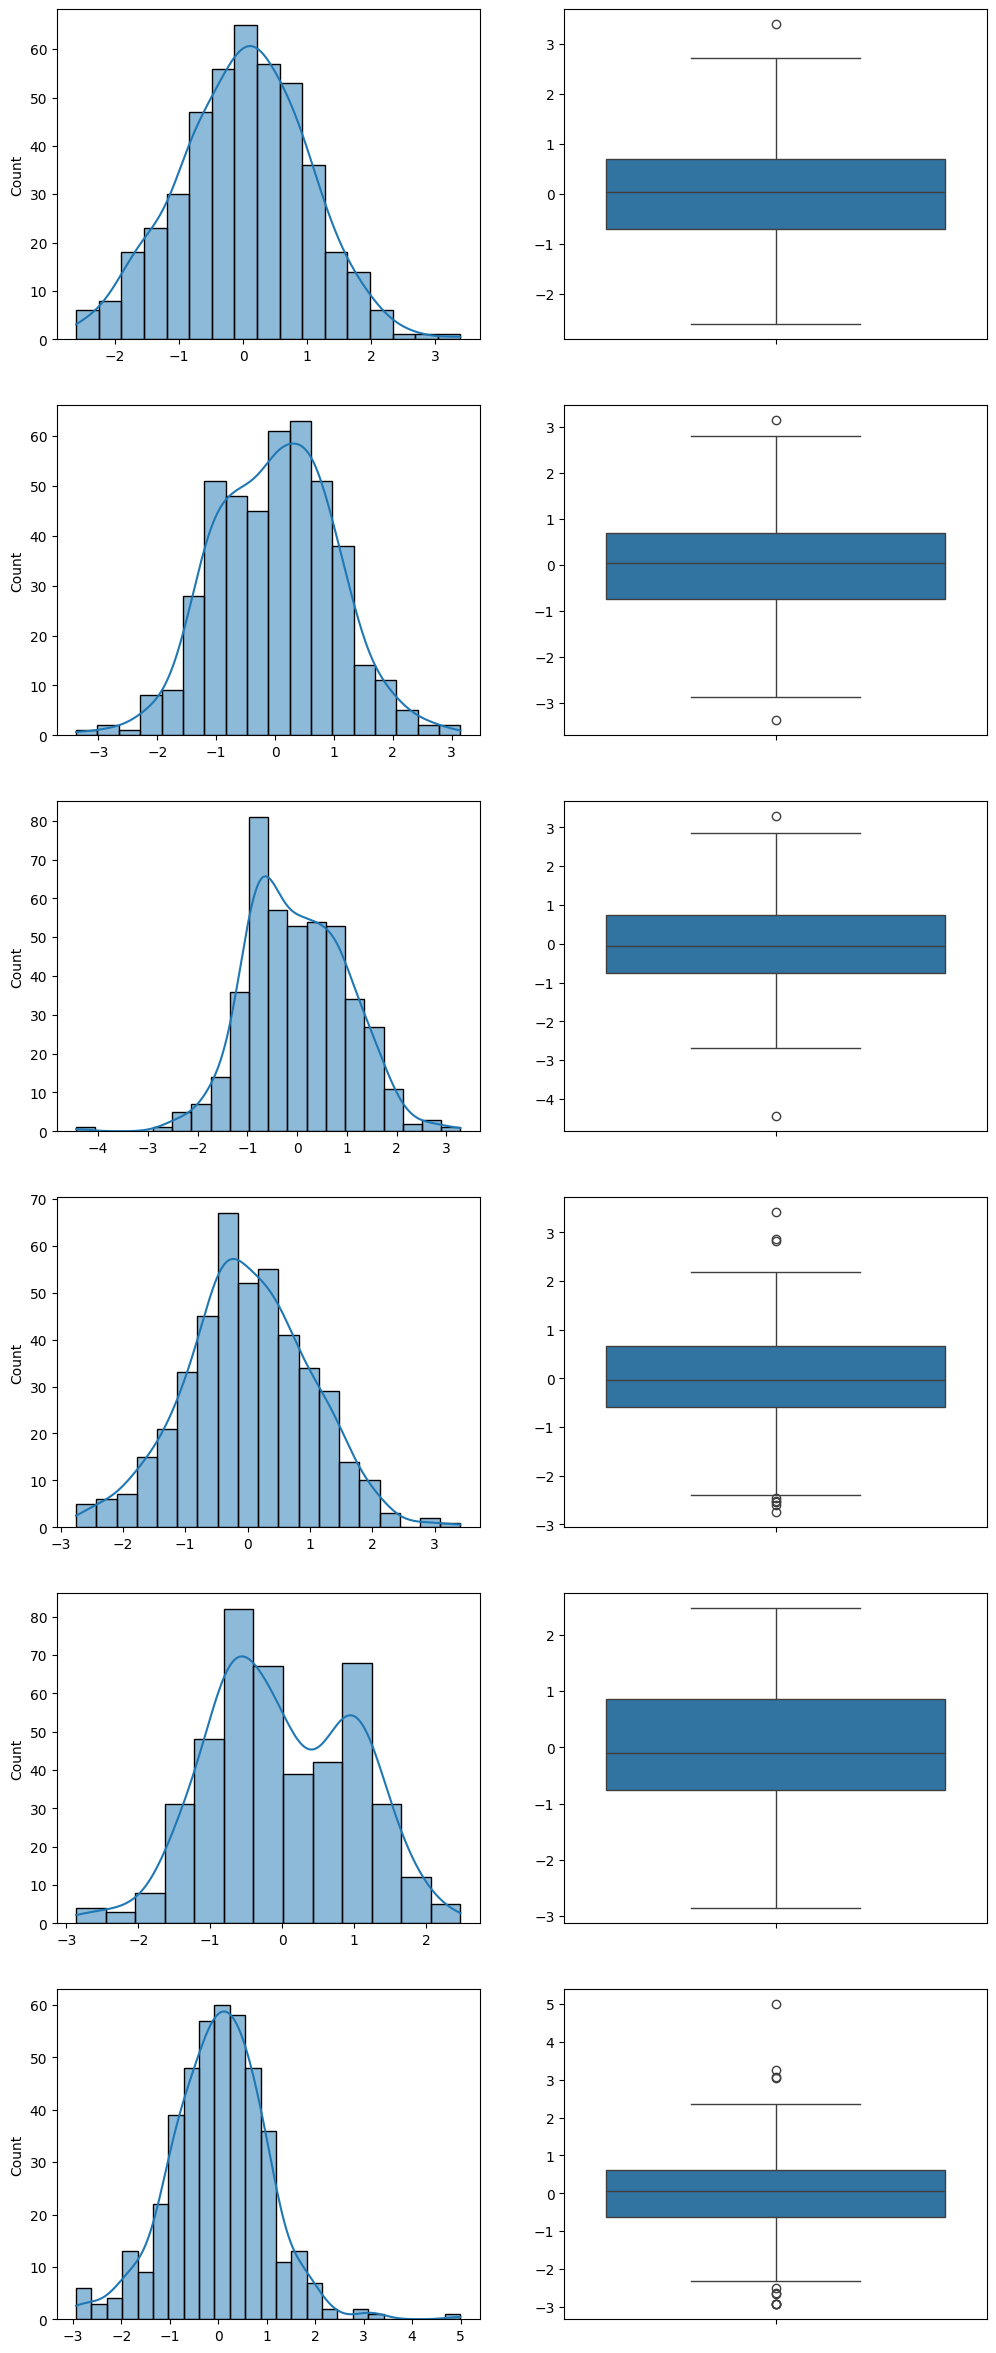

In [2319]:

fig, axes = plt.subplots(6,2, figsize = (12,30))

for i in range(0, X_std.shape[1]):
    sns.histplot(x= X_std[:,i], kde=True, ax=axes[i][0])
    sns.boxplot(y=X_std[:,i], ax=axes[i][1])

In [2320]:
def handle_outliers(col):
    q1, q2, q3 = np.quantile(col, [0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    return col.clip(lower, upper)

In [2321]:
customers.shape

(440, 8)

In [2322]:
# customers_without_noise = customers.copy()
# customers_without_noise[features] = customers_without_noise[features].apply(handle_outliers)
# customers_without_noise.shape

In [2323]:
#X = customers_without_noise[features]

In [2324]:
#X_std = preprocessor.fit_transform(X)

In [2325]:
model_kmeans = KMeans(n_clusters=5)
model_kmeans.fit(X_std)
labels_kmeans = model_kmeans.predict(X_std)
labels_kmeans


array([2, 2, 2, 4, 1, 2, 3, 2, 3, 2, 2, 4, 2, 2, 2, 0, 3, 4, 2, 3, 4, 0,
       1, 1, 1, 3, 4, 0, 2, 4, 2, 4, 0, 4, 0, 3, 1, 2, 3, 4, 1, 4, 3, 3,
       3, 2, 2, 1, 2, 2, 4, 3, 4, 3, 4, 3, 2, 3, 0, 3, 3, 2, 2, 2, 4, 3,
       3, 2, 4, 0, 4, 1, 4, 4, 2, 0, 4, 2, 0, 3, 0, 3, 2, 4, 3, 2, 2, 1,
       0, 4, 0, 4, 2, 4, 3, 3, 3, 0, 0, 4, 2, 2, 2, 1, 4, 4, 3, 2, 3, 3,
       4, 2, 4, 4, 4, 0, 0, 4, 4, 4, 4, 0, 0, 3, 4, 1, 4, 2, 3, 4, 4, 0,
       0, 0, 0, 0, 2, 3, 4, 4, 4, 4, 4, 4, 0, 2, 0, 4, 0, 4, 0, 0, 4, 4,
       0, 2, 2, 4, 2, 3, 2, 0, 4, 2, 3, 2, 2, 3, 0, 0, 3, 2, 3, 3, 0, 3,
       4, 4, 4, 4, 2, 1, 3, 1, 3, 0, 0, 3, 2, 3, 4, 0, 0, 3, 0, 4, 1, 2,
       4, 0, 2, 2, 1, 0, 0, 3, 0, 3, 3, 2, 4, 2, 0, 2, 3, 2, 3, 4, 2, 0,
       0, 3, 0, 4, 0, 4, 2, 0, 0, 4, 4, 3, 4, 3, 4, 3, 0, 4, 0, 4, 1, 4,
       4, 2, 2, 2, 0, 0, 4, 4, 0, 2, 4, 2, 1, 4, 3, 4, 1, 4, 0, 0, 4, 4,
       3, 1, 2, 4, 2, 0, 0, 0, 3, 4, 0, 0, 4, 0, 4, 2, 0, 2, 4, 4, 1, 0,
       0, 4, 0, 0, 0, 4, 4, 2, 4, 3, 4, 3, 2, 0, 2,

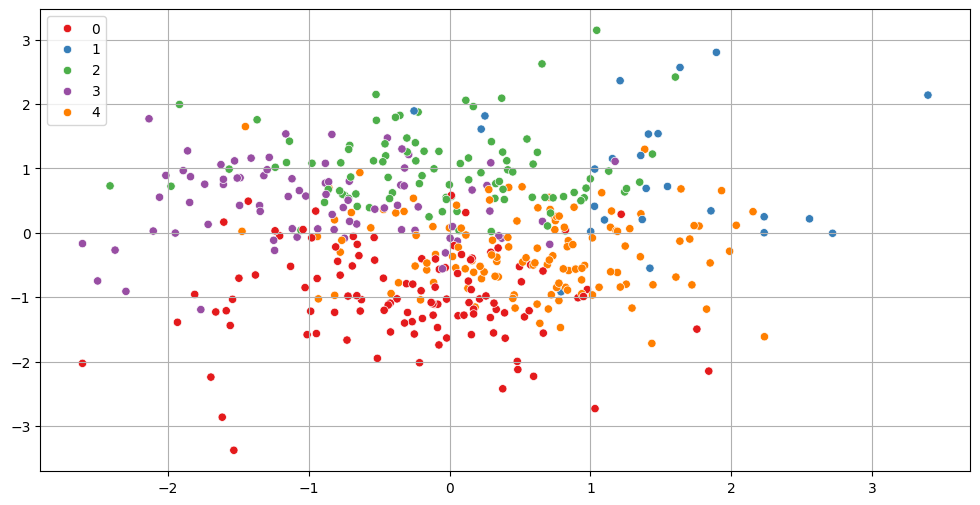

In [2326]:

plt.figure(figsize=(12,6))
sns.scatterplot(x=X_std[:,0], y=X_std[:,1], hue=labels_kmeans, palette="Set1")
plt.grid()

In [2327]:
K = list(range(2, 10, 1))
wcss_list = []

for k in K:
    model = KMeans(n_clusters=k)
    model.fit(X_std)
    wcss = model.inertia_
    wcss_list.append(wcss)

print(wcss_list)

[1810.5594098835943, 1520.2814303252335, 1352.2119840422774, 1284.8309512374183, 1187.6208567750941, 1098.0928266783558, 1040.5253909002327, 972.3551112882358]


In [2328]:
silhouette_score(X_std, labels_kmeans, metric='euclidean')

0.17738793226052102

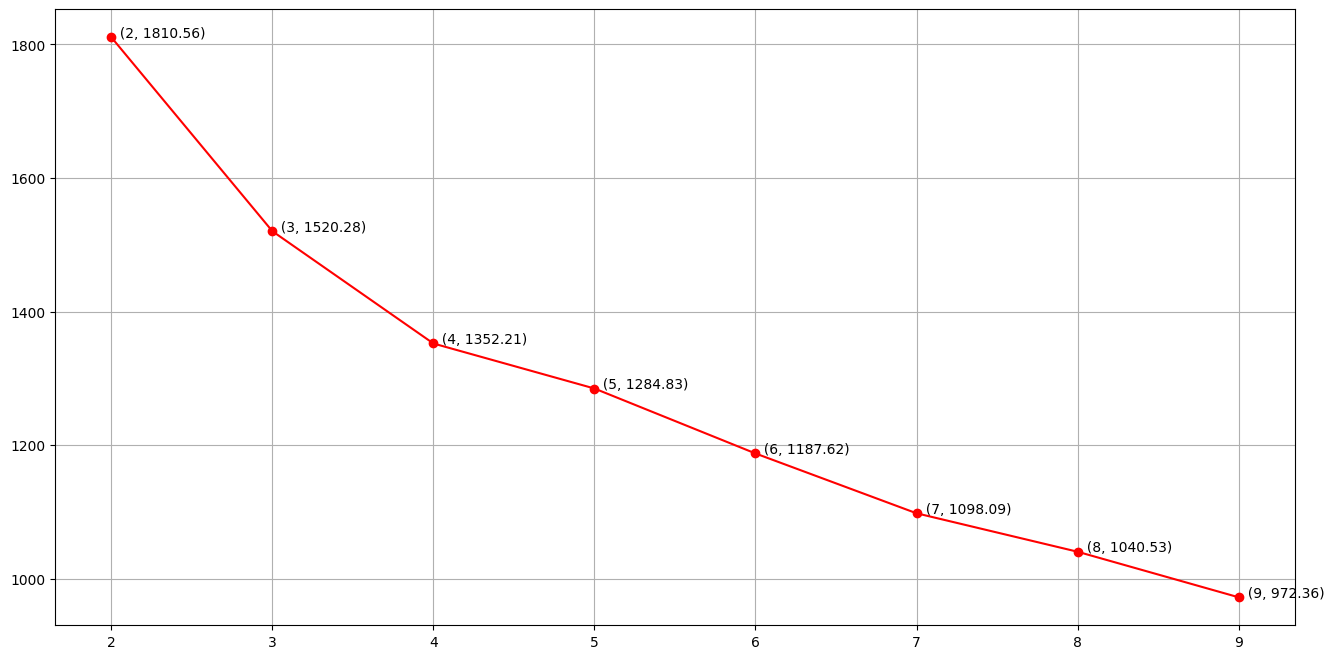

In [2329]:
plt.figure(figsize=(16,8))
plt.plot(K, wcss_list, "ro-")

for x, y in zip(K, wcss_list):
    plt.text(x, y, f"  ({x}, {y:.2f})")
plt.grid()

In [2330]:
final_dbscan = DBSCAN(eps = best_eps, min_samples=best_min_points)
final_dbscan_labels = final_dbscan.fit_predict(X_std)
silhouette_score(X_std, final_dbscan_labels, metric='euclidean')

-0.37553028176200226

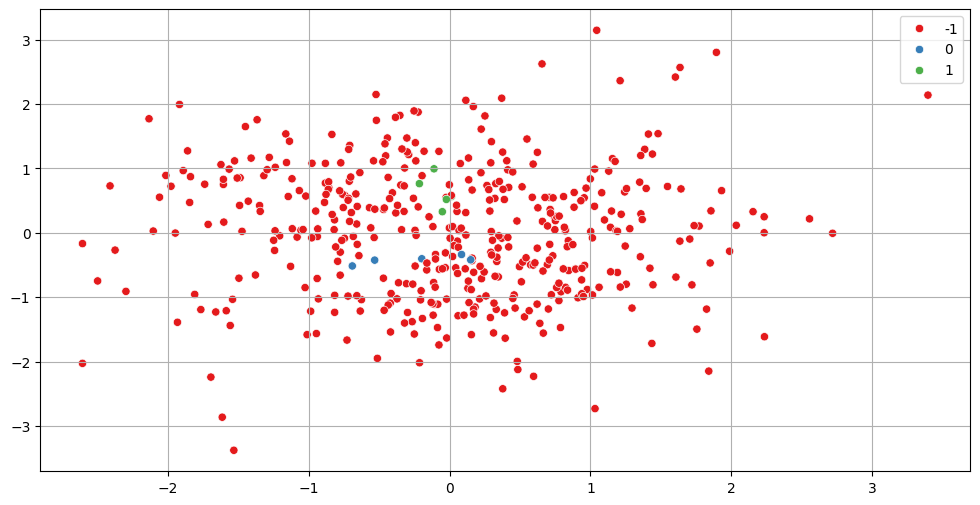

In [2331]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=X_std[:,0], y=X_std[:,1], hue=final_dbscan_labels, palette="Set1")
plt.grid()

In [2332]:
model_agg = AgglomerativeClustering(n_clusters=7, linkage='ward')
labels_agg = model_agg.fit_predict(X_std)
silhouette_score(X_std, labels_agg, metric='euclidean')

0.1592635354889306

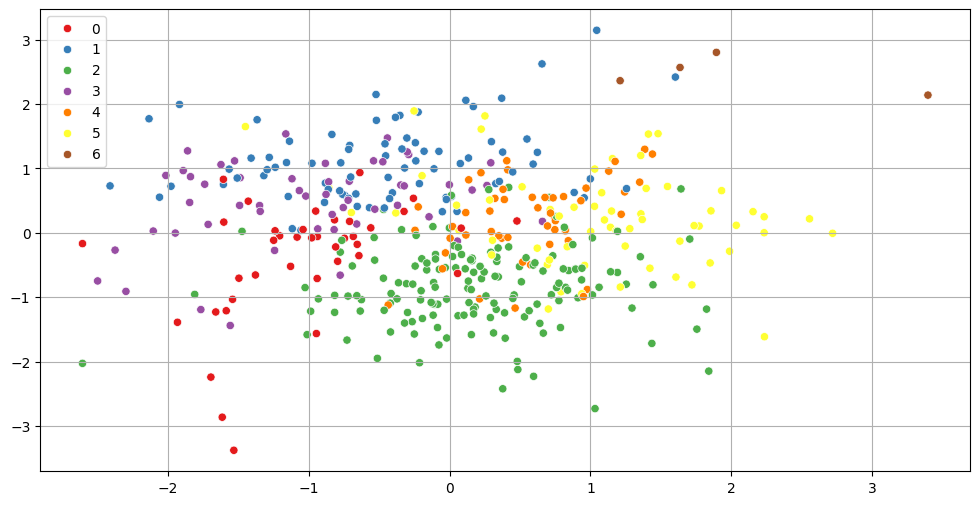

In [2333]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=X_std[:,0], y=X_std[:,1], hue=labels_agg, palette="Set1")
plt.grid()